# Base de Dados Escolhida para Estudo:
Ocorrências Aeronáuticas - ANAC
https://dados.gov.br/dados/conjuntos-dados/ocorrencias-aeronauticas

# Metadados:
https://www.anac.gov.br/acesso-a-informacao/dados-abertos/areas-de-atuacao/seguranca-operacional/ocorrencias-aeronauticas/76-ocorrencias-aeronauticas

# Dados Auxiliares
PDF: MCA 3-6 - Manual de Investigação do SIPAER
https://www2.fab.mil.br/cenipa/index.php/anexos/24-legsipaer

IDH:


# Descrição dos Atributos da Base de Dados
Campo:-									Descrição  
Número da Ocorrência:-					Número da Ocorrência Aeronáutica  
Classificação da Ocorrência:-			Classificação da Ocorrência Aeronáutica  
Data da Ocorrência:-					Data (UTC) da Ocorrência Aeronáutica  
Hora da Ocorrência:-					Hora (UTC) da Ocorrência Aeronáutica  
Município:-								Município do local da Ocorrência, quando aplicável  
UF:-									UF do local da Ocorrência, quando aplicável  
Latitude:-								Latitude do local onde houve a ocorrência  
Longitude:-								Longitude do local onde houve a ocorrência  
Tipo de Aeródromo:-						Tipo de Aeródromo em que houve a ocorrência, quando aplicável.  
​Histórico:-								Descrição sobre a ocorrência  
Matrícula:-								Matrícula da Aeronave associada à Ocorrência Aeronáutica  
Categoria da Aeronave:-					Categoria da Aeronave associada à Ocorrência Aeronáutica  
Operador:-								Operador da Aeronave associada à Ocorrência Aeronáutica  
Tipo de Ocorrência:-					Tipo de Ocorrência de acordo com a taxonomia ADREP  
Fase da Operação:-						Fase da Operação da Aeronave quando da Ocorrência Aeronáutica  
Operação:-								Tipo de Operação da Aeronave no momento da Ocorrência Aeronáutica  
Danos à Aeronave:-						Danos à Aeronave associada à Ocorrência Aeronáutica  
Aeródromo de Destino:-					Indicador de Localidade ICAO do Aeródromo de Destino da Aeronave associada à Ocorrência Aeronáutica  
Aeródromo de Origem:-					Indicador de Localidade ICAO do Aeródromo de Origem da Aeronave associada à Ocorrência Aeronáutica  
Lesões Fatais - Tripulantes:-			Número de Tripulantes com lesões fatais na Aeronave associada à Ocorrência Aeronáutica  
Lesões Fatais – Passageiros:-			Número de Passageiros com lesões fatais na Aeronave associada à Ocorrência Aeronáutica  
Lesões Fatais - Terceiros:-				Número de Terceiros com lesões fatais causadas pela Aeronave associada à Ocorrência Aeronáutica  
Lesões Graves – Tripulantes:-			Número de Tripulantes com lesões graves na Aeronave associada à Ocorrência Aeronáutica  
Lesões Graves – Passageiros:-			Número de Passageiros com lesões graves na Aeronave associada à Ocorrência Aeronáutica  
Lesões Graves – Terceiros:-				Número de Terceiros com lesões graves causadas pela Aeronave associada à Ocorrência Aeronáutica  
Lesões Leves - Tripulantes:-			Número de Tripulantes com lesões leves na Aeronave associada à Ocorrência Aeronáutica  
Lesões Leves – Passageiros:-			Número de Passageiros com lesões leves na Aeronave associada à Ocorrência Aeronáutica  
Lesões Leves - Terceiros:-				Número de Terceiros com lesões leves causadas pela Aeronave associada à Ocorrência Aeronáutica  
Ilesos – Tripulantes:-					Número de Tripulantes ilesos na Aeronave associada à Ocorrência Aeronáutica  
Ilesos – Passageiros:-					Número de Passageiros ilesos na Aeronave associada à Ocorrência Aeronáutica  
Lesões Desconhecidas – Tripulantes:-	Número de Tripulantes com lesões desconhecida na Aeronave associada à Ocorrência Aeronáutica  
Lesões Desconhecidas – Passageiros:-	Número de Passageiros com lesões desconhecida na Aeronave associada à Ocorrência Aeronáutica  
Lesões Desconhecidas - Terceiros:-		Número de Terceiros com lesões desconhecida causadas pela Aeronave associada à Ocorrência Aeronáutica  
PSSO:-									A ocorrência é considerada nos indicadores do Programa de Supervisão da Segurança Operacional (PSSO)  
Número da Ficha:-						Número da ficha cadastrada pelo CENIPA para a ocorrência.  
Operador Padronizado:-					Nome do operador/empresa, padronizado pelo sistema, responsável pela aeronave na época da ocorrência.  
Região:-								Região do País relacionada ao campo UF.  
ICAO:-									Código ICAO do aeródromo onde houve a ocorrência.  
Modelo:-								Descrição do Modelo da Aeronave  
CLS:-									Código que identifica o tipo da aeronave.  
Tipo ICAO:-								Código de identificação da aeronave segundo a ICAO.  
PMD:-									Peso máximo de Decolagem da aeronave  
Número de Assentos:-					Quantidade de assentos disponíveis na aeronave.  
Nome do Fabricante:-					Nome da empresa fabricante da aeronave.  
​Descrição Tipo:-						Descrição do tipo da ocorrência​  


# Recorte Temporal do Estudo
ano inicial: 2012  
ano final: 2024  
motivo: Para melhor analise com a tabela de IDH  

# Quais as Perguntas  
1- Quais os 3 tipos mais comuns de ocorrência por estado?  
2- Qual o indice de ocorrências por região por ano?  
3- Quais fases das operações geram mais acidentes?  
4- Qual o total de fatalidades por operação por ano?  
5- Qual o tipo mais comum de ocorrência por categoria da aeronave?  
6- Qual a categoria de aeronave com menor indice de fatalidades? (total de fatalidades / total de ocorrências / número de acentos*)  
7- Correlação entre Quantidade de Ocorrências e Evolução do IDH do Estado no decorrer do tempo.  
  
*normalização para comparação com demais aeronaves

# Importando Bibliotecas

In [14]:
import pandas as pd
import numpy as np
import requests
from io import StringIO

# Importando a base de dados do GitHub

In [ ]:
def carregar_csv_github(url_raw: str, sep: str = ",", skiprows: int = 0) -> pd.DataFrame:
    """
    Baixa um CSV público do GitHub e retorna como DataFrame pandas adaptável.
    """
    response = requests.get(url_raw, timeout=30)
    response.raise_for_status()

    # Lê o arquivo aplicando as configurações passadas nos argumentos
    df_lido = pd.read_csv(
        StringIO(response.text),
        sep=sep,
        skiprows=skiprows,
        on_bad_lines='skip'
    )

    # Transforma a string textual 'null' no valor NaN real do sistema
    df_limpo = df_lido.replace('null', np.nan)

    return df_limpo

# ==============================================================
# CARREGANDO E EXIBINDO A BASE DO CENIPA (Ocorrências)
# ==============================================================
csv_path_cenipa = "https://raw.githubusercontent.com/Jobanu/Projeto-Final-DS-PY-004/main/Dados/V_OCORRENCIA_AMPLA.csv"

# Carrega usando vírgula (sep=",") e pulando a primeira linha (skiprows=1)
df = carregar_csv_github(csv_path_cenipa, sep=";", skiprows=1)

print(f"--- BASE CENIPA: Carregadas {len(df)} ocorrências ---")
display(df.head())


# ==============================================================
# CARREGANDO E EXIBINDO A BASE DO IDH
# ==============================================================
csv_path_idhm = "https://raw.githubusercontent.com/Jobanu/Projeto-Final-DS-PY-004/desenvolvimento/Dados/IDHM.csv"

# Carrega usando ponto e vírgula (sep=";") e sem pular linhas (skiprows=0)
df_idhm = carregar_csv_github(csv_path_idhm, sep=";", skiprows=0)

print(f"\n--- BASE IDH: Carregadas {len(df_idhm)} linhas de estados ---")
display(df_idhm.head())


# ==============================================================
# CARREGANDO BASE AUXILIAR CATEGORIA_AERONAVE
# ==============================================================
csv_path_categoria_aeronave = "https://raw.githubusercontent.com/Jobanu/Projeto-Final-DS-PY-004/desenvolvimento/Dados/CATEGORIA_AERONAVE.csv"

# Carrega usando ponto e vírgula (sep=",") e sem pular linhas (skiprows=0)
df_categoria_aeronave = carregar_csv_github(csv_path_categoria_aeronave, sep=",", skiprows=0)


# Faz a separação (Cria as duas colunas novas)
df_categoria_aeronave[['Categoria_da_Aeronave', 'Nome da categoria']] = df_categoria_aeronave.iloc[:, 0].str.split(',', n=1, expand=True)

# --- LINHA NOVA: Apaga a coluna velha e grudada que sobrou ---
df_categoria_aeronave = df_categoria_aeronave.drop(columns=['Categoria_da_Aeronave,Nome da categoria'])


print(f"\n--- BASE Categorias: Carregadas {len(df_categoria_aeronave)} linhas de estados ---")
display(df_categoria_aeronave.head())

--- BASE CENIPA: Carregadas 5021 ocorrências ---


,Numero_da_Ocorrencia,Numero_da_Ficha,Operador_Padronizado,Classificacao_da_Ocorrencia,Data_da_Ocorrencia,Hora_da_Ocorrencia,Municipio,UF,Regiao,Descricao_do_Tipo,ICAO,Latitude,Longitude,Tipo_de_Aerodromo,Historico,Matricula,Categoria_da_Aeronave,Operador,Tipo_de_Ocorrencia,Fase_da_Operacao,Operacao,Danos_a_Aeronave,Aerodromo_de_Destino,Aerodromo_de_Origem,Lesoes_Fatais_Tripulantes,Lesoes_Fatais_Passageiros,Lesoes_Fatais_Terceiros,Lesoes_Graves_Tripulantes,Lesoes_Graves_Passageiros,Lesoes_Graves_Terceiros,Lesoes_Leves_Tripulantes,Lesoes_Leves_Passageiros,Lesoes_Leves_Terceiros,Ilesos_Tripulantes,Ilesos_Passageiros,Lesoes_Desconhecidas_Tripulantes,Lesoes_Desconhecidas_Passageiros,Lesoes_Desconhecidas_Terceiros,Modelo,CLS,Tipo_ICAO,PMD,Numero_de_Assentos,Nome_do_Fabricante,PSSO
0,36746,2023765949,NITZ AVIACAO AGRICOLA LTDA. - EPP,Acidente,2023-03-23,11:20:00,PASSO DO SOBRADO,RS,Sul,EXCURSÃO DE PISTA,APUA,"-29,4316","-52,114",APUA,Durante a corrida para decolagem da área de po...,PRNVC,S11,NITZ AVIACAO AGRICOLA LTDA,RE,Decolagem,Operação Especializada,Substancial,APUA,APUA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,A188B,L1P,C188,1497.0,1.0,CESSNA AIRCRAFT,verdadeiro
1,38381,202385892466,ENOCK RESENDE JUNIOR,Acidente,2023-07-09,16:00:00,SANTANA DO RIACHO,MG,Sudeste,OUTROS,Fora de Aeródromo,"-19,205","-43,3712",-,A aeronave decolou do aeródromo da Serra do Ci...,PUAPV,PET,ENOCK RESENDE JUNIOR,OTHR,Voo a baixa altura,Voo Experimental,Substancial,SNLG,SNLG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,H2,G1P,ZZZZ,500.0,2.0,ENOCK RESENDE JUNIOR,verdadeiro
2,36409,2023525502,MS ARMAZENS GERAIS LTDA.,Incidente Grave,2023-02-16,19:00:00,TAILÂNDIA,PA,Norte,COLISÃO COM OBSTÁCULO DURANTE A DECOLAGEM E POUSO,Aeródromo não cadastrado,"-2,5908","-48,5324",NaN,A aeronave decolou do Aeródromo Fazenda Itália...,PRVVZ,TPP,MS ARMAZENS GERAIS LTDA.,CTOL,Aproximação,Voo Privado,Substancial,SWGZ,SD37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,SR22,L1P,SR22,1542.0,4.0,CIRRUS DESIGN,verdadeiro
3,31607,2022464840,ADRIANO AUGUSTO PECLAT DE PAULA,Incidente Grave,2022-03-27,13:50,PIRENÓPOLIS,GO,Centro-Oeste,EXCURSÃO DE PISTA,SNMH,"-15,8492","-48,9826",Público,A aeronave decolou do Aeródromo Nacional de Av...,PRGPN,TPP,ADRIANO AUGUSTO PECLAT DE PAULA,RE,Corrida após pouso,Voo Privado,Leve,SNMH,SBNV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,NaN,NaN,NaN,PA-28R-201T,L1P,P28R,1315.0,4.0,PIPER AIRCRAFT,verdadeiro
4,31607,2022464840,ANTONIO PAULO MACHADO GONTIJO,Incidente Grave,2022-03-27,13:50,PIRENÓPOLIS,GO,Centro-Oeste,FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPON...,SNMH,"-15,8492","-48,9826",Público,A aeronave decolou do Aeródromo Nacional de Av...,PRGPN,TPP,ANTONIO PAULO MACHADO GONTIJO,SCF-NP,Corrida após pouso,Voo Privado,Leve,SNMH,SBNV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,NaN,NaN,NaN,PA-28R-201T,L1P,P28R,1315.0,4.0,PIPER AIRCRAFT,verdadeiro



--- BASE IDH: Carregadas 28 linhas de estados ---


,Territorialidades,IDHM 2012,Faixa_de_IDHM,IDHM 2013,Faixa_de_IDHM.1,IDHM 2014,Faixa_de_IDHM.2,IDHM 2015,Faixa_de_IDHM.3,IDHM 2016,Faixa_de_IDHM.4,IDHM 2017,Faixa_de_IDHM.5,IDHM 2018,Faixa_de_IDHM.6,IDHM 2019,Faixa_de_IDHM.7,IDHM 2020,Faixa_de_IDHM.8,IDHM 2021,Faixa_de_IDHM.9,IDHM 2022,Faixa_de_IDHM.10,IDHM 2023,Faixa_de_IDHM.11,IDHM 2024,Faixa_de_IDHM.12
0,BR,0.744,Alto,0.752,Alto,0.760,Alto,0.762,Alto,0.767,Alto,0.770,Alto,0.777,Alto,0.782,Alto,0.776,Alto,0.757,Alto,0.788,Alto,0.798,Alto,0.805,Muito Alto
1,AC,0.705,Alto,0.709,Alto,0.719,Alto,0.719,Alto,0.723,Alto,0.711,Alto,0.731,Alto,0.738,Alto,0.736,Alto,0.702,Alto,0.732,Alto,0.740,Alto,0.754,Alto
2,AL,0.657,Medio,0.653,Medio,0.670,Medio,0.669,Medio,0.680,Medio,0.682,Medio,0.694,Medio,0.693,Medio,0.694,Medio,0.691,Medio,0.722,Alto,0.739,Alto,0.746,Alto
3,AP,0.709,Alto,0.735,Alto,0.726,Alto,0.728,Alto,0.732,Alto,0.731,Alto,0.737,Alto,0.732,Alto,0.707,Alto,0.681,Medio,0.743,Alto,0.767,Alto,0.759,Alto
4,AM,0.706,Alto,0.717,Alto,0.720,Alto,0.724,Alto,0.723,Alto,0.743,Alto,0.732,Alto,0.739,Alto,0.725,Alto,0.700,Alto,0.757,Alto,0.764,Alto,0.767,Alto



--- BASE Categorias: Carregadas 89 linhas de estados ---


,Categoria_da_Aeronave,Nome da categoria
0,ADD,ADMINISTRAÇÃO DIRETA DO DISTRITO FEDERAL
1,ADE,ADMINISTRAÇÃO DIRETA ESTADUAL
2,ADF,ADMINISTRAÇÃO DIRETA FEDERAL
3,ADM,ADMINISTRAÇÃO DIRETA MUNICIPAL
4,AID,ADMINISTRAÇÃO INDIRETA DO DISTRITO FEDERAL


In [16]:
tamanho_df_inicio = len(df)
print(f"Tamanho inicial do DataFrame: {tamanho_df_inicio}")
memoria_df_inicio = df.memory_usage(deep=True).sum()
print(f"Tamanho inicial do DataFrame bytes: {memoria_df_inicio}")

Tamanho inicial do DataFrame: 5021
Tamanho inicial do DataFrame bytes: 11788464


# Explorando a base de dados

In [17]:
# Dimensões
df.shape

(5021, 45)

In [18]:
# Visualizando as 5 primeiras linhas
df.head()

,Numero_da_Ocorrencia,Numero_da_Ficha,Operador_Padronizado,Classificacao_da_Ocorrencia,Data_da_Ocorrencia,Hora_da_Ocorrencia,Municipio,UF,Regiao,Descricao_do_Tipo,...,Lesoes_Desconhecidas_Tripulantes,Lesoes_Desconhecidas_Passageiros,Lesoes_Desconhecidas_Terceiros,Modelo,CLS,Tipo_ICAO,PMD,Numero_de_Assentos,Nome_do_Fabricante,PSSO
0,36746,2023765949,NITZ AVIACAO AGRICOLA LTDA. - EPP,Acidente,2023-03-23,11:20:00,PASSO DO SOBRADO,RS,Sul,EXCURSÃO DE PISTA,...,NaN,NaN,NaN,A188B,L1P,C188,1497.0,1.0,CESSNA AIRCRAFT,verdadeiro
1,38381,202385892466,ENOCK RESENDE JUNIOR,Acidente,2023-07-09,16:00:00,SANTANA DO RIACHO,MG,Sudeste,OUTROS,...,NaN,NaN,NaN,H2,G1P,ZZZZ,500.0,2.0,ENOCK RESENDE JUNIOR,verdadeiro
2,36409,2023525502,MS ARMAZENS GERAIS LTDA.,Incidente Grave,2023-02-16,19:00:00,TAILÂNDIA,PA,Norte,COLISÃO COM OBSTÁCULO DURANTE A DECOLAGEM E POUSO,...,NaN,NaN,NaN,SR22,L1P,SR22,1542.0,4.0,CIRRUS DESIGN,verdadeiro
3,31607,2022464840,ADRIANO AUGUSTO PECLAT DE PAULA,Incidente Grave,2022-03-27,13:50,PIRENÓPOLIS,GO,Centro-Oeste,EXCURSÃO DE PISTA,...,NaN,NaN,NaN,PA-28R-201T,L1P,P28R,1315.0,4.0,PIPER AIRCRAFT,verdadeiro
4,31607,2022464840,ANTONIO PAULO MACHADO GONTIJO,Incidente Grave,2022-03-27,13:50,PIRENÓPOLIS,GO,Centro-Oeste,FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPON...,...,NaN,NaN,NaN,PA-28R-201T,L1P,P28R,1315.0,4.0,PIPER AIRCRAFT,verdadeiro


In [19]:
# Visualizando as 5 últimas linhas
df.tail()

,Numero_da_Ocorrencia,Numero_da_Ficha,Operador_Padronizado,Classificacao_da_Ocorrencia,Data_da_Ocorrencia,Hora_da_Ocorrencia,Municipio,UF,Regiao,Descricao_do_Tipo,...,Lesoes_Desconhecidas_Tripulantes,Lesoes_Desconhecidas_Passageiros,Lesoes_Desconhecidas_Terceiros,Modelo,CLS,Tipo_ICAO,PMD,Numero_de_Assentos,Nome_do_Fabricante,PSSO
5016,11300,200511226153045,LUG TAXI AEREO,Incidente Grave,2005-11-22,01:20:00,PIRACICABA,SP,Sudeste,COLISÃO COM AVE,...,0.0,0.0,0.0,EMB-820C CARAJA,L2T,PAT4,3629.0,8.0,EMBRAER,verdadeiro
5017,11280,PT-WOF 05MAI2020 20H46 SERIPA2,CASA CIVIL,Incidente Grave,2020-05-05,20:46:00,FORTALEZA,CE,Nordeste,FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPON...,...,0.0,0.0,0.0,B200,L2T,BE20,5670.0,10.0,BEECH AIRCRAFT,verdadeiro
5018,26249,202084338,PLA &amp; SILVA AVIACAO AGRICOLA LTDA,Acidente,2020-12-06,13:30,SANTA VITÓRIA DO PALMAR,RS,Sul,COMBUSTÍVEL,...,NaN,NaN,NaN,EMB-202,L1P,IPAN,1800.0,1.0,EMBRAER,verdadeiro
5019,11277,PU-DGH 21ABR2020 18H00 SERIPA3,AG ESCOLA DE AVIACAO LEVE LTDA,Acidente,2020-04-21,18:00:00,JAGUARÉ,ES,Sudeste,MANOBRA ABRUPTA,...,0.0,0.0,0.0,BRAVO700,L1P,ULAC,600.0,2.0,AEROBRAVO INDÚSTRIA AERONÁUTICA LTDA,verdadeiro
5020,11277,PU-DGH 21ABR2020 18H00 SERIPA3,AG ESCOLA DE AVIACAO LEVE LTDA,Acidente,2020-04-21,18:00:00,JAGUARÉ,ES,Sudeste,PERDA DE CONTROLE EM VOO,...,0.0,0.0,0.0,BRAVO700,L1P,ULAC,600.0,2.0,AEROBRAVO INDÚSTRIA AERONÁUTICA LTDA,verdadeiro


In [20]:
# Visualizando os Metadados do Dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5021 entries, 0 to 5020
Data columns (total 45 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Numero_da_Ocorrencia              5021 non-null   int64  
 1   Numero_da_Ficha                   5019 non-null   object 
 2   Operador_Padronizado              4945 non-null   object 
 3   Classificacao_da_Ocorrencia       5021 non-null   object 
 4   Data_da_Ocorrencia                5021 non-null   object 
 5   Hora_da_Ocorrencia                3588 non-null   object 
 6   Municipio                         3627 non-null   object 
 7   UF                                5018 non-null   object 
 8   Regiao                            4351 non-null   object 
 9   Descricao_do_Tipo                 4379 non-null   object 
 10  ICAO                              1687 non-null   object 
 11  Latitude                          3531 non-null   object 
 12  Longit

Atributos de [Data_da_Ocorrencia] e [Hora_da_Ocorrencia] carregados como object, é necessário ajustar este carregamento no comando de leitura do .csv:  
 4   Data_da_Ocorrencia                5021 non-null   object   
 5   Hora_da_Ocorrencia                3588 non-null   object  

 45 Colunas disponíveis. Será necessário selecionar as colunas próprias para o estudo, uma vez que fica inviável tratar todos dados nulls, vazios, outliners e depois não usar esses dados para o estudo.  
   

Será Necessário tratamento com cruzamento deste dados para preencimento do que for possível:  
Municipio                           1394  
UF                                     3  
Regiao                               670  

# Calculando NaN na Base de Dados Crua

In [21]:
def calcular_nan_por_atributo(df_NaN: pd.DataFrame) -> pd.DataFrame:
  # Calcula o número de valores NaN para cada coluna
  nan_counts = df_NaN.isnull().sum()

  # Calcula o total de registros no DataFrame
  total_records = len(df_NaN)

  # Cria um DataFrame com a contagem de NaN
  df_nan_analysis = pd.DataFrame({
      'Atributo': nan_counts.index,
      'NaN_Contagem': nan_counts.values
  })

  # Calcula o percentual de NaN's
  df_nan_analysis['NaN_Percentual'] = (df_nan_analysis['NaN_Contagem'] / total_records) * 100
  return df_nan_analysis

# Execução do código
df_nan_analysis = calcular_nan_por_atributo(df)
display(df_nan_analysis)

,Atributo,NaN_Contagem,NaN_Percentual
0,Numero_da_Ocorrencia,0,0.000000
1,Numero_da_Ficha,2,0.039833
2,Operador_Padronizado,76,1.513643
3,Classificacao_da_Ocorrencia,0,0.000000
4,Data_da_Ocorrencia,0,0.000000
5,Hora_da_Ocorrencia,1433,28.540131
6,Municipio,1394,27.763394
7,UF,3,0.059749
8,Regiao,670,13.343955
9,Descricao_do_Tipo,642,12.786298


In [22]:
df[df['UF'].isnull()][['UF', 'Historico']]

,UF,Historico
3766,NaN,Aircraft landed on RWY 24 and shortly after ma...
4705,NaN,A aeronave decolou do Aeródromo Formosa (SWFR)...
4928,NaN,"During cruise between WPT 0524N and KODOS, at ..."


É possível inferir que o atributo UF do ID 4705 é GO, os demais podem ser excluídos para o estudo de acidentes no território nacional, uma vez que, pelo histórico, ocorreram fora do território nacional.

In [23]:
df[df['Regiao'].isnull()][['UF', 'Historico']]

,UF,Historico
131,Exterior,"Immediately after take-off, with adverse meteo..."
132,Exterior,"Immediately after take-off, with adverse meteo..."
137,Exterior,A aeronave teve problemas no motor nº 1 durant...
369,Indeterminado,NaN
402,Indeterminado,"A aeronave decolou de local não registrado, co..."
...,...,...
4705,NaN,A aeronave decolou do Aeródromo Formosa (SWFR)...
4715,Exterior,Confidence Rating: Information is only availab...
4716,Exterior,Seaplane flooded during landing. Cockpit and f...
4851,Exterior,The Aircraft took off from Hong Kong Internati...


Podemos Excluir os registros com atributos [UF] == Exterior, uma vez que se trata de ocorrências fora do território nacional e, portanto, fora do range deste estudo que se restringe as ocorrências em território nacional.  
Podemos Excluir os registros com atributos [UF] == Indeterminado e [Histórico] == NaN, pois não dá para determinar o Estado da ocorrência para o estudo.  
Os demais Indeterminados, podem ser inferidos pelo histórico, mas devemos considerar o custo de uma Machine Learning para extrair esta informação ou fazer manualmente um a um.

Após o tratamento, devemos fazer a correlação [UF] x [Regiao] para preencher os dados faltantes de [Regiao] atráves dos dados existentes de [UF]

# Filtros do Estudo
1 - [Numero_da_Ocorrencia] (tratando como indice)  
2 - [Classificacao_da_Ocorrencia]? 'Acidente' e/ou 'Incidente Grave'  
3 - Período do estudo baseado em [Data_da_Ocorrencia]  
# Atributos de Interesse para as perguntas
1- agrupar por([UF]); contar([Tipo_de_Ocorrencia]); <-corresponde([Descricao_do_Tipo]); filtra(ano([Data_da_Ocorrencia]))  
  
2- agrupar por [Regiao]; agrupar por ano([Data_da_Ocorrencia]); média(soma([Lesoes_Fatais_Tripulantes]) soma([Lesoes_Fatais_Passageiros]) soma([Lesoes_Fatais_Terceiros]))  
  
3- agrupar por [Fase_da_Operacao]; contar([Numero_da_Ocorrencia])  
  
4- agrupar por [Fase_da_Operacao]; soma(soma([Lesoes_Fatais_Tripulantes]) soma([Lesoes_Fatais_Passageiros]) soma([Lesoes_Fatais_Terceiros])  
  
5- agrupar por [Categoria_da_Aeronave]; agrupar por [Tipo_de_Ocorrencia]. contar([Numero_da_Ocorrencia])  

6- agrupar por [Categoria_da_Aeronave]; 	soma(soma([Lesoes_Fatais_Tripulantes]) soma([Lesoes_Fatais_Passageiros]) soma([Lesoes_Fatais_Terceiros]) /
										contagem([Numero_da_Ocorrencia]) /
										soma([Numero_de_Assentos])


In [24]:
Atritubos_interesse = [
    'Numero_da_Ocorrencia',
    'Data_da_Ocorrencia',
    'Historico',
    'UF',
    'Regiao',
    'Tipo_de_Ocorrencia',
    'Descricao_do_Tipo',
    'Operacao',
    'Lesoes_Fatais_Tripulantes',
    'Lesoes_Fatais_Passageiros',
    'Lesoes_Fatais_Terceiros',
    'Lesoes_Graves_Tripulantes',
    'Lesoes_Graves_Passageiros',
    'Lesoes_Graves_Terceiros',
    'Lesoes_Leves_Tripulantes',
    'Lesoes_Leves_Passageiros',
    'Lesoes_Leves_Terceiros',
    'Ilesos_Tripulantes',
    'Ilesos_Passageiros',
    'Lesoes_Desconhecidas_Tripulantes',
    'Lesoes_Desconhecidas_Passageiros',
    'Lesoes_Desconhecidas_Terceiros',
    'Fase_da_Operacao',
    'Categoria_da_Aeronave',
    'Numero_de_Assentos'
    ]

Será necessário estudar o forma de preencher os dados Nulls nestes Atributos, pois são atributos de interesse no estudo:  
Lesoes_Fatais_Tripulantes           1118  
Lesoes_Fatais_Passageiros           1239  
Lesoes_Fatais_Terceiros             1319  
Lesoes_Graves_Tripulantes           1168  
Lesoes_Graves_Passageiros           1281  
Lesoes_Graves_Terceiros             1327  
Lesoes_Leves_Tripulantes            1124  
Lesoes_Leves_Passageiros            1277  
Lesoes_Leves_Terceiros              1327  
Ilesos_Tripulantes                   410  
Ilesos_Passageiros                   949  
Lesoes_Desconhecidas_Tripulantes    1315  
Lesoes_Desconhecidas_Passageiros    1326  
Lesoes_Desconhecidas_Terceiros      1327  

In [25]:
# 1. Lista com as colunas de lesões e contagem da base
colunas_lesoes = [
    'Lesoes_Fatais_Tripulantes', 'Lesoes_Fatais_Passageiros', 'Lesoes_Fatais_Terceiros',
    'Lesoes_Graves_Tripulantes', 'Lesoes_Graves_Passageiros', 'Lesoes_Graves_Terceiros',
    'Lesoes_Leves_Tripulantes', 'Lesoes_Leves_Passageiros', 'Lesoes_Leves_Terceiros',
    'Ilesos_Tripulantes', 'Ilesos_Passageiros',
    'Lesoes_Desconhecidas_Tripulantes', 'Lesoes_Desconhecidas_Passageiros', 'Lesoes_Desconhecidas_Terceiros'
]

df[colunas_lesoes].head(10)

,Lesoes_Fatais_Tripulantes,Lesoes_Fatais_Passageiros,Lesoes_Fatais_Terceiros,Lesoes_Graves_Tripulantes,Lesoes_Graves_Passageiros,Lesoes_Graves_Terceiros,Lesoes_Leves_Tripulantes,Lesoes_Leves_Passageiros,Lesoes_Leves_Terceiros,Ilesos_Tripulantes,Ilesos_Passageiros,Lesoes_Desconhecidas_Tripulantes,Lesoes_Desconhecidas_Passageiros,Lesoes_Desconhecidas_Terceiros
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,10.0,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,10.0,NaN,NaN,NaN


# Relendo o CSV com os novos filtros

In [26]:
# Importando a base de dados do GitHub com filtros
def carregar_csv_github2(url_raw: str, pula_linha = 1) -> pd.DataFrame:
    """
    Baixa um CSV público do GitHub e retorna como DataFrame pandas.
    url_raw: Caminho no GitHub para o arquivo .CSV
    """
    response = requests.get(url_raw, timeout=30)
    response.raise_for_status()

    # 1. Lê o arquivo agora com somente os atributos de interesse
    # e com configuração de correta da [Data_da_Ocorrencia]
    df_lido = pd.read_csv(
        StringIO(response.text),
        sep=';',
        skiprows=pula_linha,
        on_bad_lines='skip',
        usecols=Atritubos_interesse,
        parse_dates=['Data_da_Ocorrencia']
    )

    # 2. Transforma a string textual 'null' no valor NaN real do sistema
    df_limpo = df_lido.replace('null', np.nan)

    # 3. Retorna o DataFrame perfeitamente estruturado
    return df_limpo

# Execução do código
df = carregar_csv_github2(csv_path_cenipa)

print(f"Carregadas {len(df)} ocorrências")

Carregadas 5021 ocorrências


# Verificando as novas dimensões do Dataframe

In [27]:
df.shape

(5021, 25)

In [28]:
df.head()

,Numero_da_Ocorrencia,Data_da_Ocorrencia,UF,Regiao,Descricao_do_Tipo,Historico,Categoria_da_Aeronave,Tipo_de_Ocorrencia,Fase_da_Operacao,Operacao,...,Lesoes_Graves_Terceiros,Lesoes_Leves_Tripulantes,Lesoes_Leves_Passageiros,Lesoes_Leves_Terceiros,Ilesos_Tripulantes,Ilesos_Passageiros,Lesoes_Desconhecidas_Tripulantes,Lesoes_Desconhecidas_Passageiros,Lesoes_Desconhecidas_Terceiros,Numero_de_Assentos
0,36746,2023-03-23,RS,Sul,EXCURSÃO DE PISTA,Durante a corrida para decolagem da área de po...,S11,RE,Decolagem,Operação Especializada,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0
1,38381,2023-07-09,MG,Sudeste,OUTROS,A aeronave decolou do aeródromo da Serra do Ci...,PET,OTHR,Voo a baixa altura,Voo Experimental,...,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,2.0
2,36409,2023-02-16,PA,Norte,COLISÃO COM OBSTÁCULO DURANTE A DECOLAGEM E POUSO,A aeronave decolou do Aeródromo Fazenda Itália...,TPP,CTOL,Aproximação,Voo Privado,...,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,4.0
3,31607,2022-03-27,GO,Centro-Oeste,EXCURSÃO DE PISTA,A aeronave decolou do Aeródromo Nacional de Av...,TPP,RE,Corrida após pouso,Voo Privado,...,NaN,NaN,NaN,NaN,1.0,2.0,NaN,NaN,NaN,4.0
4,31607,2022-03-27,GO,Centro-Oeste,FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPON...,A aeronave decolou do Aeródromo Nacional de Av...,TPP,SCF-NP,Corrida após pouso,Voo Privado,...,NaN,NaN,NaN,NaN,1.0,2.0,NaN,NaN,NaN,4.0


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5021 entries, 0 to 5020
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Numero_da_Ocorrencia              5021 non-null   int64         
 1   Data_da_Ocorrencia                5021 non-null   datetime64[ns]
 2   UF                                5018 non-null   object        
 3   Regiao                            4351 non-null   object        
 4   Descricao_do_Tipo                 4379 non-null   object        
 5   Historico                         4756 non-null   object        
 6   Categoria_da_Aeronave             5012 non-null   object        
 7   Tipo_de_Ocorrencia                4379 non-null   object        
 8   Fase_da_Operacao                  3721 non-null   object        
 9   Operacao                          4927 non-null   object        
 10  Lesoes_Fatais_Tripulantes         3903 non-null 

In [30]:
print(df.isna().sum())
df_nan_analysis_novo = calcular_nan_por_atributo(df)
display(df_nan_analysis_novo)

Numero_da_Ocorrencia                   0
Data_da_Ocorrencia                     0
UF                                     3
Regiao                               670
Descricao_do_Tipo                    642
Historico                            265
Categoria_da_Aeronave                  9
Tipo_de_Ocorrencia                   642
Fase_da_Operacao                    1300
Operacao                              94
Lesoes_Fatais_Tripulantes           1118
Lesoes_Fatais_Passageiros           1239
Lesoes_Fatais_Terceiros             1319
Lesoes_Graves_Tripulantes           1168
Lesoes_Graves_Passageiros           1281
Lesoes_Graves_Terceiros             1327
Lesoes_Leves_Tripulantes            1124
Lesoes_Leves_Passageiros            1277
Lesoes_Leves_Terceiros              1327
Ilesos_Tripulantes                   410
Ilesos_Passageiros                   949
Lesoes_Desconhecidas_Tripulantes    1315
Lesoes_Desconhecidas_Passageiros    1326
Lesoes_Desconhecidas_Terceiros      1327
Numero_de_Assent

,Atributo,NaN_Contagem,NaN_Percentual
0,Numero_da_Ocorrencia,0,0.000000
1,Data_da_Ocorrencia,0,0.000000
2,UF,3,0.059749
3,Regiao,670,13.343955
4,Descricao_do_Tipo,642,12.786298
5,Historico,265,5.277833
6,Categoria_da_Aeronave,9,0.179247
7,Tipo_de_Ocorrencia,642,12.786298
8,Fase_da_Operacao,1300,25.891257
9,Operacao,94,1.872137


# Iniciando o tratamento dos Dados

## Lesões

## Tratamento das colunas dos tipos de Lesões - (NaN para 0)

A razão para escolhermos apenas as colunas de lesões e não o DataFrame inteiro é que o significado do "vazio" (NaN) muda completamente dependendo do tipo de dado da coluna. Substituir tudo por zero de forma automática geraria graves erros de lógica e distorções na análise.

1. Colunas de Texto (Strings) ficariam sem sentido

    - Operador: O responsável pelo voo passaria a se chamar 0 (o Pandas não saberia que ali deveria ser "Desconhecido")
    Matricula: O prefixo do avião viraria 0.

2. Colunas Numéricas Específicas seriam corrompidas, pois o número 0 possui um valor matemático real em engenharia aeronáutica.

    - PMD (Peso Máximo de Decolagem): Se uma aeronave experimental não teve o peso registrado, colocar 0 faria o Pandas calcular que o avião pesa zero quilos, o que estragaria qualquer média de peso que você tentasse fazer no projeto.
    - Numero_de_Assentos: Colocar 0 indicaria que o avião voava sem nenhum banco dentro, quando na verdade o dado apenas não foi coletado.

3. Nas colunas de Lesões, o 0 mantém a lógica perfeitaNas colunas de contagem de pessoas (Lesoes_Fatais, Lesoes_Graves), assumir que o vazio equivale a 0 é seguro e correto para o modelo de dados, pois:

    - Se o relatório não mencionou feridos, a hipótese estatística padrão é que zero pessoas se machucaram naquela categoria específica.
    - Permite converter a coluna de Float (número quebrado) para Int (número inteiro), já que não existem "1.5 pessoas mortas".

In [31]:
# 1. Lista com as colunas de lesões e contagem da base
colunas_lesoes = [
    'Lesoes_Fatais_Tripulantes', 'Lesoes_Fatais_Passageiros', 'Lesoes_Fatais_Terceiros',
    'Lesoes_Graves_Tripulantes', 'Lesoes_Graves_Passageiros', 'Lesoes_Graves_Terceiros',
    'Lesoes_Leves_Tripulantes', 'Lesoes_Leves_Passageiros', 'Lesoes_Leves_Terceiros',
    'Ilesos_Tripulantes', 'Ilesos_Passageiros',
    'Lesoes_Desconhecidas_Tripulantes', 'Lesoes_Desconhecidas_Passageiros', 'Lesoes_Desconhecidas_Terceiros'
]

# --- ANTES ---
print("=== 1. QUANTIDADE DE NaNs ANTES DA LIMPEZA ===")
# Soma quantos NaNs existem apenas nas colunas da lista
print(df[colunas_lesoes].isna().sum())
print("-" * 50)


# 2. Criar a função de preenchimento
def preencher_nan_lesoes(dataframe: pd.DataFrame, lista_colunas: list) -> pd.DataFrame:
    """
    Substitui os valores NaN das colunas de lesões pelo número zero (0).
    Aplica a conversão para tipo inteiro (Int64), ideal para contagens.
    """
    # Faz uma cópia para não alterar o DataFrame original por acidente
    df_copia = dataframe.copy()

    # Preenche os NaNs com 0 e converte para tipo numérico inteiro
    df_copia[lista_colunas] = df_copia[lista_colunas].fillna(0).astype('int64')

    return df_copia


# 3. Aplicar a função no seu DataFrame
df = preencher_nan_lesoes(df, colunas_lesoes)


# --- DEPOIS ---
print("=== 2. QUANTIDADE DE NaNs DEPOIS DA LIMPEZA ===")
print(df[colunas_lesoes].isna().sum())
print("-" * 50)



=== 1. QUANTIDADE DE NaNs ANTES DA LIMPEZA ===
Lesoes_Fatais_Tripulantes           1118
Lesoes_Fatais_Passageiros           1239
Lesoes_Fatais_Terceiros             1319
Lesoes_Graves_Tripulantes           1168
Lesoes_Graves_Passageiros           1281
Lesoes_Graves_Terceiros             1327
Lesoes_Leves_Tripulantes            1124
Lesoes_Leves_Passageiros            1277
Lesoes_Leves_Terceiros              1327
Ilesos_Tripulantes                   410
Ilesos_Passageiros                   949
Lesoes_Desconhecidas_Tripulantes    1315
Lesoes_Desconhecidas_Passageiros    1326
Lesoes_Desconhecidas_Terceiros      1327
dtype: int64
--------------------------------------------------
=== 2. QUANTIDADE DE NaNs DEPOIS DA LIMPEZA ===
Lesoes_Fatais_Tripulantes           0
Lesoes_Fatais_Passageiros           0
Lesoes_Fatais_Terceiros             0
Lesoes_Graves_Tripulantes           0
Lesoes_Graves_Passageiros           0
Lesoes_Graves_Terceiros             0
Lesoes_Leves_Tripulantes            0
L

## Valores únicos

In [32]:
# Lista para armazenar os dados dos valores únicos de cada coluna
dados_valores_unicos = []

# Itera sobre cada coluna do DataFrame df
for coluna in df.columns:
    valor_unico = df[coluna].unique()
    numero_valores_unicos = len(valor_unico)
    dados_valores_unicos.append({
        'Coluna': coluna,
        'Valores_Unicos': valor_unico.tolist(), # Converte array numpy para lista
        'Numero_de_Valores_Unicos': numero_valores_unicos
    })

# Cria um DataFrame a partir dos dados coletados
df_valores_unicos = pd.DataFrame(dados_valores_unicos)

print('==== Resumo de Valores Únicos por Atributo no df ====\n')
# Exibe o DataFrame resultante
display(df_valores_unicos)

==== Resumo de Valores Únicos por Atributo no df ====



,Coluna,Valores_Unicos,Numero_de_Valores_Unicos
0,Numero_da_Ocorrencia,"[36746, 38381, 36409, 31607, 43009, 30005, 314...",4301
1,Data_da_Ocorrencia,"[2023-03-23 00:00:00, 2023-07-09 00:00:00, 202...",3268
2,UF,"[RS, MG, PA, GO, CE, MT, SP, MA, RO, BA, RJ, M...",30
3,Regiao,"[Sul, Sudeste, Norte, Centro-Oeste, Nordeste, ...",6
4,Descricao_do_Tipo,"[EXCURSÃO DE PISTA, OUTROS, COLISÃO COM OBSTÁC...",35
5,Historico,[Durante a corrida para decolagem da área de p...,4039
6,Categoria_da_Aeronave,"[S11, PET, TPP, D20, S05, TPX, PRI, TPR, Sem m...",58
7,Tipo_de_Ocorrencia,"[RE, OTHR, CTOL, SCF-NP, SCF-PP, ARC, LALT, LO...",35
8,Fase_da_Operacao,"[Decolagem, Voo a baixa altura, Aproximação, C...",28
9,Operacao,"[Operação Especializada, Voo Experimental, Voo...",13


## [Numero_de_Assentos]

In [33]:
df['Numero_de_Assentos'].isna().sum()

np.int64(149)

Trantando o [Numero_de_assentos] pela média existente calculada pela [Categoria_da_Aeronave]

In [34]:
media_assentos_por_categoria = df.groupby('Categoria_da_Aeronave')['Numero_de_Assentos'].mean().reset_index()
media_assentos_por_categoria = media_assentos_por_categoria.dropna(subset=['Numero_de_Assentos'])
media_assentos_por_categoria['Numero_de_Assentos'] = media_assentos_por_categoria['Numero_de_Assentos'].astype('int64')
display(media_assentos_por_categoria)

,Categoria_da_Aeronave,Numero_de_Assentos
0,ADD,5
1,ADE,6
2,ADF,7
3,AID,6
4,AIF,6
5,ALE,2
6,AMD,2
7,D05,5
8,D08,4
9,D13,1


In [35]:
# Criar um dicionário de mapeamento de Categoria_da_Aeronave para Numero_de_Assentos médios
assentos_medios_dict = media_assentos_por_categoria.set_index('Categoria_da_Aeronave')['Numero_de_Assentos'].to_dict()

# Mapear os valores médios para a coluna 'Numero_de_Assentos' do df
# Usar apply com uma função lambda para preencher apenas NaNs
df['Numero_de_Assentos'] = df.apply(
    lambda row: assentos_medios_dict.get(row['Categoria_da_Aeronave'], row['Numero_de_Assentos'])
    if pd.isna(row['Numero_de_Assentos']) else row['Numero_de_Assentos'],
    axis=1
)

# Converter a coluna para int64 após o preenchimento, se necessário (lidando com NaNs remanescentes, se houver)
df['Numero_de_Assentos'] = df['Numero_de_Assentos'].fillna(0).astype('int64')

print(f"NaNs restantes em 'Numero_de_Assentos': {df['Numero_de_Assentos'].isnull().sum()}")
display(df[['Categoria_da_Aeronave', 'Numero_de_Assentos']].head())

NaNs restantes em 'Numero_de_Assentos': 0


,Categoria_da_Aeronave,Numero_de_Assentos
0,S11,1
1,PET,2
2,TPP,4
3,TPP,4
4,TPP,4


## [UF] e [Região]

### [UF]

In [36]:
df['UF'].isna().sum()

np.int64(3)

In [37]:
df[df['UF'].isnull()][['Numero_da_Ocorrencia', 'UF', 'Historico']]

,Numero_da_Ocorrencia,UF,Historico
3766,25805,NaN,Aircraft landed on RWY 24 and shortly after ma...
4705,46147,NaN,A aeronave decolou do Aeródromo Formosa (SWFR)...
4928,36986,NaN,"During cruise between WPT 0524N and KODOS, at ..."


Com o [Numero_da_Ocorrencia] 46147 já tratado, vamos agora remover as ocorrências onde a [UF] ainda está como nula. Conforme a análise anterior, estas são ocorrências fora do território nacional e não são relevantes para o estudo.

In [38]:
#Conforme Histórico, ID 4705 tem a UF em GO
df.loc[df['Numero_da_Ocorrencia'] == 46147, 'UF'] = 'GO'
display(df[df['UF'].isnull()][['Numero_da_Ocorrencia', 'UF', 'Historico']])

,Numero_da_Ocorrencia,UF,Historico
3766,25805,NaN,Aircraft landed on RWY 24 and shortly after ma...
4928,36986,NaN,"During cruise between WPT 0524N and KODOS, at ..."


In [39]:
df.dropna(subset=['UF'], inplace=True)
print(f"NaNs restantes em 'UF': {df['UF'].isnull().sum()}")

NaNs restantes em 'UF': 0


### [Regiao]

Vamos preencher os valores ausentes no atributo [Regiao] do df. Para isso, usaremos o dicionário regioes_brasil para mapear cada [UF] à sua Regiao correspondente.

In [40]:
# Dicionário de Regiões do Brasil
regioes_brasil = {
    "Norte": ["AC", "AM", "AP", "PA", "RO", "RR", "TO"],
    "Nordeste": ["AL", "BA", "CE", "MA", "PB", "PE", "PI", "RN", "SE"],
    "Centro-Oeste": ["DF", "GO", "MT", "MS"],
    "Sudeste": ["ES", "MG", "RJ", "SP"],
    "Sul": ["PR", "RS", "SC"]
}


In [41]:
# Inverter o dicionário para mapear UF para Região
uf_para_regiao = {
    uf: regiao
    for regiao, ufs in regioes_brasil.items()
    for uf in ufs
}

# Criar um Series com as novas regiões mapeadas a partir da UF
# Valores de UF que não estão no dicionário resultarão em NaN aqui
regioes_mapeadas = df['UF'].map(uf_para_regiao)

# Preencher APENAS os NaN em 'Regiao' com os valores de 'regioes_mapeadas'
# O aviso FuturegWarning é resolvido ao atribuir o resultado de volta à coluna
df['Regiao'] = df['Regiao'].fillna(regioes_mapeadas)

print(f"NaNs restantes em 'Regiao': {df['Regiao'].isnull().sum()}")

NaNs restantes em 'Regiao': 667


Vamos investigar quais valores de [UF] não foram mapeados e ainda resultam em NaN na coluna [Regiao].

In [42]:
ufs_nao_mapeadas = df[df['Regiao'].isnull()]['UF'].unique()
print(f"UFs que não foram mapeadas para 'Regiao': {ufs_nao_mapeadas.tolist()}")

UFs que não foram mapeadas para 'Regiao': ['Exterior', 'Indeterminado']


Vamos proceder à remoção dos registros contendo 'Exterior', pois não faram parte do estudo

In [43]:
# Remove as linhas onde 'UF' == 'Exterior'
df = df[~df['UF'].isin(['Exterior'])]

# Verifica novamente os NaNs na coluna 'Regiao' após a remoção
print(f"NaNs restantes em 'Regiao' após a remoção de 'Exterior': {df['Regiao'].isnull().sum()}")

NaNs restantes em 'Regiao' após a remoção de 'Exterior': 655


Vamos remover os registros onde a [UF] é 'Indeterminado' e o [Historico] está NaN.

In [44]:
# Remove as linhas onde 'UF' é 'Indeterminado' E 'Historico' é NaN
df = df[~((df['UF'] == 'Indeterminado') & (df['Historico'].isnull()))]

# Verifica novamente os NaNs na coluna 'Regiao' após a remoção e re-mapeamento
print(f"NaNs restantes em 'Regiao' após a remoção de 'Indeterminado' com Historico NaN: {df['Regiao'].isnull().sum()}")

NaNs restantes em 'Regiao' após a remoção de 'Indeterminado' com Historico NaN: 521


Como não está no escopo do estudo a utilização de Machine Learning, IA Generativa ou Agentes de IA para tratamento dos dados, usando o [Historico] como dado para inferencia da [UF], vamos excluir os demais Indeterminados para continuação do estudo.  
A mesma decisão será usada nas demais análises.

In [45]:
# Remove as linhas onde 'UF' == 'Indeterminado'
df = df[~df['UF'].isin(['Indeterminado'])]

# Verifica novamente os NaNs na coluna 'Regiao' após a remoção
print(f"NaNs restantes em 'Regiao' após a remoção de 'Indeterminado': {df['Regiao'].isnull().sum()}")

NaNs restantes em 'Regiao' após a remoção de 'Indeterminado': 0


## [Fase_da_Operacao]

In [46]:
display(df[df['Fase_da_Operacao'].isnull()][['Fase_da_Operacao', 'Descricao_do_Tipo', 'Historico']])

,Fase_da_Operacao,Descricao_do_Tipo,Historico
29,NaN,INDETERMINADO,A aeronave foi encontrada acidentada em Uberlâ...
191,NaN,NaN,NaN
205,NaN,NaN,NaN
236,NaN,NaN,NaN
289,NaN,OUTROS,NaN
...,...,...,...
4848,NaN,INDETERMINADO,Segundo informações divulgadas em veículos de ...
4866,NaN,NaN,NaN
4867,NaN,NaN,NaN
4868,NaN,NaN,NaN


Não é possível inferir uma [Fase_da_Operação] a partir dos dados que temos para preenchimento dos registros com NaN, portanto, optamos por excluir do estudo estes registros.

In [47]:
df.dropna(subset=['Fase_da_Operacao'], inplace=True)
print(f"NaNs restantes em 'Fase_da_Operacao': {df['Fase_da_Operacao'].isnull().sum()}")

NaNs restantes em 'Fase_da_Operacao': 0


## [Tipo_de_Ocorrencia]

In [48]:
df_tp_null = df[df['Tipo_de_Ocorrencia'].isnull()][['Numero_da_Ocorrencia', 'Tipo_de_Ocorrencia', 'Descricao_do_Tipo', 'Historico']]
df_tp_null.to_csv('df_tp_null.csv', index=False)
df_tp_null

,Numero_da_Ocorrencia,Tipo_de_Ocorrencia,Descricao_do_Tipo,Historico
678,11346,NaN,NaN,APÓS O POUSO FOI OBSERVADO QUE HAVIA SINALIZAÇ...
716,4559,NaN,NaN,"O helicóptero decolou de Tucuruí – PA (SBTU), ..."
815,4617,NaN,NaN,"A aeronave, com 178 passageiros e 13 tripulant..."
836,4576,NaN,NaN,A AERONAVE DECOLOU DO AEROPORTO INTERNACIONAL ...
1753,8312,NaN,NaN,A AERONAVE DECOLOU AERÓDROMO COSTA ESMERALDA (...
2156,4284,NaN,NaN,"SEGUNDO DECLARAÇÃO DO PILOTO, APÓS O POUSO NA ..."
2167,4283,NaN,NaN,O ULTRALEVE DECOLOU DO SÍTIO DE VÔO DO CLUBE D...
3214,5204,NaN,NaN,DURANTE VÔO DE PULVERIZAÇÃO OCORREU PERDA DE P...
3283,5179,NaN,NaN,NaN
3345,5154,NaN,NaN,NaN


Como temos 20 ocorrências, vamos analisar e atualizar manualmente os dados de tipo de ocorrência, de acordo com a tabela de Tipos de Ocorrências do 'MCA 3-6 - Manual de Investigação do SIPAER' - Anexo C, pags. 359 - 380.  
Faremos os acertos usando o df_tp_null.csv criado, retornando com um o tp_null_acertado.csv com os valores a serem corrigidos.


In [49]:
# Importando a base de dados do GitHub
def carregar_csv_github(url_raw: str, pula_linha = 1) -> pd.DataFrame:
    """
    Baixa um CSV público do GitHub e retorna como DataFrame pandas.
    url_raw: Caminho no GitHub para o arquivo .CSV
    """
    response = requests.get(url_raw, timeout=30)
    response.raise_for_status()

    # 1. Lê o arquivo pulando os metadados do topo
    df_lido = pd.read_csv(
        StringIO(response.text),
        sep=',',
        on_bad_lines='skip'
    )

    # 2. Transforma a string textual 'null' no valor NaN real do sistema
    df_limpo = df_lido.replace('null', np.nan)

    # 3. Retorna o DataFrame perfeitamente estruturado
    return df_limpo

# Execução do código
tp_null_path = "https://raw.githubusercontent.com/Jobanu/Projeto-Final-DS-PY-004/main/Dados/tp_null_acertado.csv"
df_tp = carregar_csv_github(tp_null_path)

print(f"Carregadas {len(df_tp)} ocorrências")


Carregadas 14 ocorrências


Com base nos dados corrigidos do df_tp contendo os acertos manuais, vamos atualizar as colunas [Tipo_de_Ocorrencia] e [Descricao_do_Tipo] no df para preencher os NaN's.

In [50]:
# Cria dicionários de mapeamento a partir de df_tp
tipo_ocorrencia_map = df_tp.set_index('Numero_da_Ocorrencia')['Tipo_de_Ocorrencia'].to_dict()
descricao_tipo_map = df_tp.set_index('Numero_da_Ocorrencia')['Descricao_do_Tipo'].to_dict()

# Identifica as linhas em df onde 'Tipo_de_Ocorrencia' é NaN
mask_tipo_nan = df['Tipo_de_Ocorrencia'].isnull()
# Identifica as linhas em df onde 'Descricao_do_Tipo' é NaN
mask_descricao_nan = df['Descricao_do_Tipo'].isnull()

# Preenche os NaNs em 'Tipo_de_Ocorrencia' usando o mapeamento
df.loc[mask_tipo_nan, 'Tipo_de_Ocorrencia'] = df.loc[mask_tipo_nan, 'Numero_da_Ocorrencia'].map(tipo_ocorrencia_map)

# Preenche os NaNs em 'Descricao_do_Tipo' usando o mapeamento
df.loc[mask_descricao_nan, 'Descricao_do_Tipo'] = df.loc[mask_descricao_nan, 'Numero_da_Ocorrencia'].map(descricao_tipo_map)

# Verifica quantos NaNs ainda existem na coluna 'Tipo_de_Ocorrencia'
remaining_nan_tipo = df['Tipo_de_Ocorrencia'].isnull().sum()
print(f"NaNs restantes em 'Tipo_de_Ocorrencia' após a atualização: {remaining_nan_tipo}")

NaNs restantes em 'Tipo_de_Ocorrencia' após a atualização: 6


As demais ocorrências seram apagadas, pois não é possível determinar estes dados.

In [51]:
df.dropna(subset=['Tipo_de_Ocorrencia'], inplace=True)
print(f"NaNs restantes em 'Tipo_de_Ocorrencia': {df['Tipo_de_Ocorrencia'].isnull().sum()}")

NaNs restantes em 'Tipo_de_Ocorrencia': 0


### [Categoria_da_Aeronave]

In [52]:
df[df['Categoria_da_Aeronave'].isnull()][['Numero_da_Ocorrencia', 'Categoria_da_Aeronave', 'Historico']]

,Numero_da_Ocorrencia,Categoria_da_Aeronave,Historico
321,40008,NaN,A aeronave decolou de uma localidade desconhec...
547,25583,NaN,A aeronave FAB5724 decolou do Aeródromo August...
941,46059,NaN,"A aeronave remotamente pilotada (RPA), modelo ..."
975,45165,NaN,A aeronave decolou do Aeródromo Municipal de S...
4621,45547,NaN,A aeronave com procedência e destino desconhec...


Não é possível definir a [Categoria_da_Aeronave] pelo [Historico], portanto, vamos excluir as linhas não preenchidas.


In [53]:
df.dropna(subset=['Categoria_da_Aeronave'], inplace=True)
print(f"NaNs restantes em 'Categoria_da_Aeronave': {df['Categoria_da_Aeronave'].isnull().sum()}")

NaNs restantes em 'Categoria_da_Aeronave': 0


Verificando dados indesejados em [Categoria_da_Aeronave]

In [54]:
print(df['Categoria_da_Aeronave'].unique())

['S11' 'PET' 'TPP' 'D20' 'S05' 'TPX' 'PRI' 'TPR' 'ADE' 'M46' 'T11' 'S07'
 'Sem matrícula' 'AMD' 'AIF' 'S51' 'Estrangeira' 'D13' 'M48' 'D15' 'M43'
 'ADF' 'M35' 'S09' 'M25' 'S59' 'M14' 'ESTRANGEIRA' 'PIN' 'AID' 'M24'
 'S05S' 'SAE' 'M37' 'INDEFINIDA' 'SAE-AG' 'S00' 'ADD' 'PEX' 'M42' 'M15'
 'TPN' 'Militar' 'M56' 'M60' 'D17' 'D08' 'D19' 'D05' 'D18' 'P50' 'S22'
 'EX2' 'ALE' 'S82']


Vamos excluir os valores 'Estrangeira' e ESTRANGEIRA', pois não é de interesse desse estudo

In [55]:
df.drop(df[df['Categoria_da_Aeronave'].isin(['Estrangeira', 'ESTRANGEIRA'])].index, inplace=True)
print(df['Categoria_da_Aeronave'].unique())

['S11' 'PET' 'TPP' 'D20' 'S05' 'TPX' 'PRI' 'TPR' 'ADE' 'M46' 'T11' 'S07'
 'Sem matrícula' 'AMD' 'AIF' 'S51' 'D13' 'M48' 'D15' 'M43' 'ADF' 'M35'
 'S09' 'M25' 'S59' 'M14' 'PIN' 'AID' 'M24' 'S05S' 'SAE' 'M37' 'INDEFINIDA'
 'SAE-AG' 'S00' 'ADD' 'PEX' 'M42' 'M15' 'TPN' 'Militar' 'M56' 'M60' 'D17'
 'D08' 'D19' 'D05' 'D18' 'P50' 'S22' 'EX2' 'ALE' 'S82']


## [operacao]

In [56]:
df[df['Operacao'].isnull()][['Numero_da_Ocorrencia', 'Operacao', 'Historico']]

,Numero_da_Ocorrencia,Operacao,Historico
185,33006,NaN,A aeronave foi vista em descida por testemunha...
186,33006,NaN,A aeronave foi vista em descida por testemunha...
416,41888,NaN,A aeronave decolou do aeródromo Campo de Marte...
542,25724,NaN,A aeronave de matrícula e modelo desconhecidos...
1508,35706,NaN,A aeronave decolou da pista da Fazenda Castanh...
1509,36147,NaN,"O paramotor decolou da cidade de Paulínia, SP,..."
4544,38948,NaN,A aeronave decolou do aeródromo Mato Grosso (S...
4545,38948,NaN,A aeronave decolou do aeródromo Mato Grosso (S...
4552,41729,NaN,A aeronave decolou de uma localidade não ident...
4606,33207,NaN,"Aeronave decolou de local desconhecido, na cid..."


Conforme analise dos dados únicos existe a possíbilidade de preenchimento como 'Desconhecida', portanto, vamos trocar os 13 registros NaN's por 'Desconhecida' para não perdermos os demais dados utéis destes regsitros.

In [57]:
df['Operacao'].fillna('Desconhecida', inplace=True)
print(f"NaNs restantes em 'Operacao': {df['Operacao'].isnull().sum()}")

NaNs restantes em 'Operacao': 0


C:\Users\joads\AppData\Local\Temp\ipykernel_25544\81402916.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Operacao'].fillna('Desconhecida', inplace=True)


### Consultando as informações do DataFrame para verificação do sucesso da limpeza de NaN's

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3597 entries, 0 to 5020
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Numero_da_Ocorrencia              3597 non-null   int64         
 1   Data_da_Ocorrencia                3597 non-null   datetime64[ns]
 2   UF                                3597 non-null   object        
 3   Regiao                            3597 non-null   object        
 4   Descricao_do_Tipo                 3597 non-null   object        
 5   Historico                         3587 non-null   object        
 6   Categoria_da_Aeronave             3597 non-null   object        
 7   Tipo_de_Ocorrencia                3597 non-null   object        
 8   Fase_da_Operacao                  3597 non-null   object        
 9   Operacao                          3597 non-null   object        
 10  Lesoes_Fatais_Tripulantes         3597 non-null   int

### [Numero_da_Ocorrencia]

Ocorrências duplicadas

In [59]:

# Calcula as ocorrencias em 'Numero_da_Ocorrencia'
conta_ocorrencias = df['Numero_da_Ocorrencia'].value_counts()

# Filtra valores que aparecem mais de uma vez
ocorrencias_repetidas = conta_ocorrencias[conta_ocorrencias > 1]

# Converte o resultado para NumPy array
ocorrencias_repetidas_array = np.array([
    [num_oc, contagem] for num_oc, contagem in ocorrencias_repetidas.items()
])

print("Valores repetidos no atributo 'Numero_da_Ocorrencia' e suas contagens:")
print(ocorrencias_repetidas_array)

Valores repetidos no atributo 'Numero_da_Ocorrencia' e suas contagens:
[[44968     6]
 [36228     6]
 [31607     4]
 ...
 [31465     2]
 [28823     2]
 [30083     2]]


Verificando a relação de tipos de Ocorrências nos Números de ocorrências repetidos.  
Queremos saber se as ocorrências repetidas estão relacionanda a tipos de ocorrências diferentes, ou seja, possíveis agentes diferentes para mesma ocorrência ou erro de registro realmente duplicado.

In [60]:
# Extrai os números de ocorrência que se repetem, a partir da análise
# anterior
numeros_ocorrencias_duplicadas = ocorrencias_repetidas.index.tolist()

# Lista para armazenar os resultados
lista_resultados_tipo_ocorrencia = []

# Itera sobre cada número de ocorrência que foi detectado como duplicado
for num_ocorrencia in numeros_ocorrencias_duplicadas:
    # Filtra o DataFrame original (df) para este número de ocorrência
    df_filtrado_por_num = df[df['Numero_da_Ocorrencia'] == num_ocorrencia]

    # Coleta todos os tipos de ocorrência únicos para este número de ocorrência
    tipos_de_ocorrencia_para_este_num = df_filtrado_por_num['Tipo_de_Ocorrencia'].unique()

    # Verifica se há mais de um tipo de ocorrência único para este número de ocorrência
    # Se houver mais de um, significa que o Tipo_de_Ocorrencia se repete (ou seja, varia)
    qtd_tipos_unicos = len(df_filtrado_por_num)
    tipo_de_ocorrencia_varia_nesta_repeticao = len(tipos_de_ocorrencia_para_este_num) > 1

    # Adiciona o resultado à lista: [número da ocorrência, lista de tipos únicos, se o tipo varia]
    lista_resultados_tipo_ocorrencia.append(
        [num_ocorrencia, tipos_de_ocorrencia_para_este_num.tolist(), tipo_de_ocorrencia_varia_nesta_repeticao, qtd_tipos_unicos]
    )

# Converte a lista de resultados em um array NumPy
# Usamos dtype=object para permitir que as listas de tipos de ocorrência tenham tamanhos variáveis
array_verificacao_tipos = np.array(lista_resultados_tipo_ocorrencia, dtype=object)

print("=== Verificação de 'Tipo_de_Ocorrencia' para 'Numero_da_Ocorrencia' repetidos ===")
print("Colunas: [Número da Ocorrência, Tipos Únicos de Ocorrência, TipSo de Ocorrência varia?]")
print(array_verificacao_tipos)

print('-' * 50)
print('Ocorrencias Verdadeiramente Dupllicadas')



=== Verificação de 'Tipo_de_Ocorrencia' para 'Numero_da_Ocorrencia' repetidos ===
Colunas: [Número da Ocorrência, Tipos Únicos de Ocorrência, TipSo de Ocorrência varia?]
[[44968 list(['SCF-PP', 'LALT']) True 6]
 [36228 list(['RE', 'LOC-G', 'SCF-NP']) True 6]
 [31607 list(['RE', 'SCF-NP']) True 4]
 ...
 [31465 list(['LALT', 'SCF-PP']) True 2]
 [28823 list(['LOC-G', 'RE']) True 2]
 [30083 list(['LOC-G', 'RE']) True 2]]
--------------------------------------------------
Ocorrencias Verdadeiramente Dupllicadas


Executando as exclusões com combinação entre [Numero_da_Ocorrencia] & [Tipo_de_Ocorrencia]

In [61]:
#Analise Antes da Execução do código
print(f"Quantidade de linhas antes da remoção de duplicatas: {len(df)}")
display(df[df['Numero_da_Ocorrencia'] == 36228])

# Remove duplicatas com base na combinação de 'Numero_da_Ocorrencia' e 'Tipo_de_Ocorrencia'
df.drop_duplicates(subset=['Numero_da_Ocorrencia', 'Tipo_de_Ocorrencia'], inplace=True)

#Analise Após a Execução do código
print(f"Quantidade de linhas após a remoção de duplicatas: {len(df)}")
display(df[df['Numero_da_Ocorrencia'] == 36228])

Quantidade de linhas antes da remoção de duplicatas: 3597


,Numero_da_Ocorrencia,Data_da_Ocorrencia,UF,Regiao,Descricao_do_Tipo,Historico,Categoria_da_Aeronave,Tipo_de_Ocorrencia,Fase_da_Operacao,Operacao,...,Lesoes_Graves_Terceiros,Lesoes_Leves_Tripulantes,Lesoes_Leves_Passageiros,Lesoes_Leves_Terceiros,Ilesos_Tripulantes,Ilesos_Passageiros,Lesoes_Desconhecidas_Tripulantes,Lesoes_Desconhecidas_Passageiros,Lesoes_Desconhecidas_Terceiros,Numero_de_Assentos
4670,36228,2023-01-30,MG,Sudeste,EXCURSÃO DE PISTA,A aeronave decolou da Pista Campo Limpo (ZZZZ)...,S11,RE,Corrida após pouso,Operação Agrícola,...,0,0,0,0,1,0,0,0,0,1
4675,36228,2023-01-30,MG,Sudeste,PERDA DE CONTROLE NO SOLO,A aeronave decolou da Pista Campo Limpo (ZZZZ)...,S11,LOC-G,Corrida após pouso,Operação Agrícola,...,0,0,0,0,1,0,0,0,0,1
4676,36228,2023-01-30,MG,Sudeste,EXCURSÃO DE PISTA,A aeronave decolou da Pista Campo Limpo (ZZZZ)...,S11,RE,Corrida após pouso,Operação Agrícola,...,0,0,0,0,1,0,0,0,0,1
4691,36228,2023-01-30,MG,Sudeste,PERDA DE CONTROLE NO SOLO,A aeronave decolou da Pista Campo Limpo (ZZZZ)...,S11,LOC-G,Corrida após pouso,Operação Agrícola,...,0,0,0,0,1,0,0,0,0,1
4697,36228,2023-01-30,MG,Sudeste,FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPON...,A aeronave decolou da Pista Campo Limpo (ZZZZ)...,S11,SCF-NP,Corrida após pouso,Operação Agrícola,...,0,0,0,0,1,0,0,0,0,1
4698,36228,2023-01-30,MG,Sudeste,FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPON...,A aeronave decolou da Pista Campo Limpo (ZZZZ)...,S11,SCF-NP,Corrida após pouso,Operação Agrícola,...,0,0,0,0,1,0,0,0,0,1


Quantidade de linhas após a remoção de duplicatas: 3468


,Numero_da_Ocorrencia,Data_da_Ocorrencia,UF,Regiao,Descricao_do_Tipo,Historico,Categoria_da_Aeronave,Tipo_de_Ocorrencia,Fase_da_Operacao,Operacao,...,Lesoes_Graves_Terceiros,Lesoes_Leves_Tripulantes,Lesoes_Leves_Passageiros,Lesoes_Leves_Terceiros,Ilesos_Tripulantes,Ilesos_Passageiros,Lesoes_Desconhecidas_Tripulantes,Lesoes_Desconhecidas_Passageiros,Lesoes_Desconhecidas_Terceiros,Numero_de_Assentos
4670,36228,2023-01-30,MG,Sudeste,EXCURSÃO DE PISTA,A aeronave decolou da Pista Campo Limpo (ZZZZ)...,S11,RE,Corrida após pouso,Operação Agrícola,...,0,0,0,0,1,0,0,0,0,1
4675,36228,2023-01-30,MG,Sudeste,PERDA DE CONTROLE NO SOLO,A aeronave decolou da Pista Campo Limpo (ZZZZ)...,S11,LOC-G,Corrida após pouso,Operação Agrícola,...,0,0,0,0,1,0,0,0,0,1
4697,36228,2023-01-30,MG,Sudeste,FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPON...,A aeronave decolou da Pista Campo Limpo (ZZZZ)...,S11,SCF-NP,Corrida após pouso,Operação Agrícola,...,0,0,0,0,1,0,0,0,0,1


## Analise Estatística Descritiva Geral

In [62]:
df.describe()

,Numero_da_Ocorrencia,Data_da_Ocorrencia,Lesoes_Fatais_Tripulantes,Lesoes_Fatais_Passageiros,Lesoes_Fatais_Terceiros,Lesoes_Graves_Tripulantes,Lesoes_Graves_Passageiros,Lesoes_Graves_Terceiros,Lesoes_Leves_Tripulantes,Lesoes_Leves_Passageiros,Lesoes_Leves_Terceiros,Ilesos_Tripulantes,Ilesos_Passageiros,Lesoes_Desconhecidas_Tripulantes,Lesoes_Desconhecidas_Passageiros,Lesoes_Desconhecidas_Terceiros,Numero_de_Assentos
count,3468.000000,3468,3468.000000,3468.000000,3468.000000,3468.000000,3468.000000,3468.000000,3468.000000,3468.000000,3468.000000,3468.000000,3468.000000,3468.000000,3468.000000,3468.00000,3468.000000
mean,15297.894464,2017-11-26 01:54:11.211072768,0.149942,0.123414,0.009227,0.062572,0.039792,0.004902,0.118512,0.080738,0.005479,0.941176,2.927336,0.015283,0.016436,0.00346,7.159458
min,1.000000,1979-11-26 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,5766.750000,2014-08-23 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,2.000000
50%,7806.000000,2018-02-28 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,4.000000
75%,28485.250000,2021-06-03 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.00000,6.000000
max,46147.000000,2024-06-22 00:00:00,4.000000,14.000000,6.000000,2.000000,6.000000,2.000000,4.000000,12.000000,4.000000,16.000000,341.000000,2.000000,7.000000,4.00000,399.000000
std,13600.108549,NaN,0.408318,0.646523,0.139744,0.266060,0.300230,0.084775,0.365947,0.513839,0.103160,1.033335,17.103712,0.140244,0.225350,0.09601,23.742458


## Criando Atributo com o Ano da Ocorrência

In [63]:
df['Data_da_Ocorrencia'] = pd.to_datetime(df['Data_da_Ocorrencia'],format='%Y-%m-%d')
df['Ano_da_Ocorrencia'] = df['Data_da_Ocorrencia'].dt.year
df.info()
display(df.head())

<class 'pandas.core.frame.DataFrame'>
Index: 3468 entries, 0 to 5020
Data columns (total 26 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Numero_da_Ocorrencia              3468 non-null   int64         
 1   Data_da_Ocorrencia                3468 non-null   datetime64[ns]
 2   UF                                3468 non-null   object        
 3   Regiao                            3468 non-null   object        
 4   Descricao_do_Tipo                 3468 non-null   object        
 5   Historico                         3458 non-null   object        
 6   Categoria_da_Aeronave             3468 non-null   object        
 7   Tipo_de_Ocorrencia                3468 non-null   object        
 8   Fase_da_Operacao                  3468 non-null   object        
 9   Operacao                          3468 non-null   object        
 10  Lesoes_Fatais_Tripulantes         3468 non-null   int

,Numero_da_Ocorrencia,Data_da_Ocorrencia,UF,Regiao,Descricao_do_Tipo,Historico,Categoria_da_Aeronave,Tipo_de_Ocorrencia,Fase_da_Operacao,Operacao,...,Lesoes_Leves_Tripulantes,Lesoes_Leves_Passageiros,Lesoes_Leves_Terceiros,Ilesos_Tripulantes,Ilesos_Passageiros,Lesoes_Desconhecidas_Tripulantes,Lesoes_Desconhecidas_Passageiros,Lesoes_Desconhecidas_Terceiros,Numero_de_Assentos,Ano_da_Ocorrencia
0,36746,2023-03-23,RS,Sul,EXCURSÃO DE PISTA,Durante a corrida para decolagem da área de po...,S11,RE,Decolagem,Operação Especializada,...,0,0,0,1,0,0,0,0,1,2023
1,38381,2023-07-09,MG,Sudeste,OUTROS,A aeronave decolou do aeródromo da Serra do Ci...,PET,OTHR,Voo a baixa altura,Voo Experimental,...,0,0,0,1,1,0,0,0,2,2023
2,36409,2023-02-16,PA,Norte,COLISÃO COM OBSTÁCULO DURANTE A DECOLAGEM E POUSO,A aeronave decolou do Aeródromo Fazenda Itália...,TPP,CTOL,Aproximação,Voo Privado,...,0,0,0,1,1,0,0,0,4,2023
3,31607,2022-03-27,GO,Centro-Oeste,EXCURSÃO DE PISTA,A aeronave decolou do Aeródromo Nacional de Av...,TPP,RE,Corrida após pouso,Voo Privado,...,0,0,0,1,2,0,0,0,4,2022
4,31607,2022-03-27,GO,Centro-Oeste,FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPON...,A aeronave decolou do Aeródromo Nacional de Av...,TPP,SCF-NP,Corrida após pouso,Voo Privado,...,0,0,0,1,2,0,0,0,4,2022


## Criando a Totalização de Lesões por Fatais, Graves, Leves, Desconhecidas, e Ilesos

In [64]:
df[colunas_lesoes].columns

Index(['Lesoes_Fatais_Tripulantes', 'Lesoes_Fatais_Passageiros',
       'Lesoes_Fatais_Terceiros', 'Lesoes_Graves_Tripulantes',
       'Lesoes_Graves_Passageiros', 'Lesoes_Graves_Terceiros',
       'Lesoes_Leves_Tripulantes', 'Lesoes_Leves_Passageiros',
       'Lesoes_Leves_Terceiros', 'Ilesos_Tripulantes', 'Ilesos_Passageiros',
       'Lesoes_Desconhecidas_Tripulantes', 'Lesoes_Desconhecidas_Passageiros',
       'Lesoes_Desconhecidas_Terceiros'],
      dtype='object')

In [65]:
df['Total_Lesoes_Fatais'] = df['Lesoes_Fatais_Tripulantes'] + df['Lesoes_Fatais_Passageiros'] + df['Lesoes_Fatais_Terceiros']
df['Total_Lesoes_Graves'] = df['Lesoes_Graves_Tripulantes'] + df['Lesoes_Graves_Passageiros'] + df['Lesoes_Graves_Terceiros']
df['Total_Lesoes_Leves'] = df['Lesoes_Leves_Tripulantes'] + df['Lesoes_Leves_Passageiros'] + df['Lesoes_Leves_Terceiros']
df['Total_Lesoes_Desconhecidas'] = df['Lesoes_Desconhecidas_Tripulantes'] + df['Lesoes_Desconhecidas_Passageiros'] + df['Lesoes_Desconhecidas_Terceiros']
df['Total_Ilesos]'] = df['Ilesos_Tripulantes'] + df['Ilesos_Passageiros']

colunas_lesoes_totais = [
    'Total_Lesoes_Fatais', 'Total_Lesoes_Graves', 'Total_Lesoes_Leves',
    'Total_Lesoes_Desconhecidas', 'Total_Ilesos'
]



Visualizando as alterações

In [66]:
display(df.head())

,Numero_da_Ocorrencia,Data_da_Ocorrencia,UF,Regiao,Descricao_do_Tipo,Historico,Categoria_da_Aeronave,Tipo_de_Ocorrencia,Fase_da_Operacao,Operacao,...,Lesoes_Desconhecidas_Tripulantes,Lesoes_Desconhecidas_Passageiros,Lesoes_Desconhecidas_Terceiros,Numero_de_Assentos,Ano_da_Ocorrencia,Total_Lesoes_Fatais,Total_Lesoes_Graves,Total_Lesoes_Leves,Total_Lesoes_Desconhecidas,Total_Ilesos]
0,36746,2023-03-23,RS,Sul,EXCURSÃO DE PISTA,Durante a corrida para decolagem da área de po...,S11,RE,Decolagem,Operação Especializada,...,0,0,0,1,2023,0,0,0,0,1
1,38381,2023-07-09,MG,Sudeste,OUTROS,A aeronave decolou do aeródromo da Serra do Ci...,PET,OTHR,Voo a baixa altura,Voo Experimental,...,0,0,0,2,2023,0,0,0,0,2
2,36409,2023-02-16,PA,Norte,COLISÃO COM OBSTÁCULO DURANTE A DECOLAGEM E POUSO,A aeronave decolou do Aeródromo Fazenda Itália...,TPP,CTOL,Aproximação,Voo Privado,...,0,0,0,4,2023,0,0,0,0,2
3,31607,2022-03-27,GO,Centro-Oeste,EXCURSÃO DE PISTA,A aeronave decolou do Aeródromo Nacional de Av...,TPP,RE,Corrida após pouso,Voo Privado,...,0,0,0,4,2022,0,0,0,0,3
4,31607,2022-03-27,GO,Centro-Oeste,FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPON...,A aeronave decolou do Aeródromo Nacional de Av...,TPP,SCF-NP,Corrida após pouso,Voo Privado,...,0,0,0,4,2022,0,0,0,0,3


## Comparação entra Dados Brutos Vs. Dados Limpos:

In [67]:
tamanho_df_final = len(df)
print("Quantidade de Registros:")
print(f'Inicial do DataFrame: {tamanho_df_inicio} Registros')
print(f"Final do DataFrame: {tamanho_df_final} Registros")
print(f'Diferença: {tamanho_df_final - tamanho_df_inicio} Registros')

print("-" * 50)

memoria_df_final = df.memory_usage(deep=True).sum()
print("Quantidade de Memória:")
print(f"Inicial do DataFrame: {memoria_df_inicio/1000000} Mb")
print(f"Final do DataFrame: {memoria_df_final/1000000} Mb")
print(f'Diferença: {(memoria_df_final - memoria_df_inicio)/1000000} Mb')

print("-" * 50)

print('Percentual de Aproveitamento de Dados')
print(f'Percentual de Registros Aproveitados: {(tamanho_df_final / tamanho_df_inicio) * 100}%')
print(f'Percentual de Redução no Uso da Memória: {(1 - (memoria_df_final / memoria_df_inicio)) * 100}%')

Quantidade de Registros:
Inicial do DataFrame: 5021 Registros
Final do DataFrame: 3468 Registros
Diferença: -1553 Registros
--------------------------------------------------
Quantidade de Memória:
Inicial do DataFrame: 11.788464 Mb
Final do DataFrame: 4.154115 Mb
Diferença: -7.634349 Mb
--------------------------------------------------
Percentual de Aproveitamento de Dados
Percentual de Registros Aproveitados: 69.06990639314877%
Percentual de Redução no Uso da Memória: 64.76118517221582%


# Tratamento do DataFrame de IDH

In [68]:
colunas_manter = ['Territorialidades', 'IDHM 2012', 'IDHM 2013', 'IDHM 2014', 'IDHM 2015',
                  'IDHM 2016', 'IDHM 2017', 'IDHM 2018', 'IDHM 2019', 'IDHM 2020',
                  'IDHM 2021', 'IDHM 2022', 'IDHM 2023', 'IDHM 2024']

# ==========================================================
# PARTE 1: Transforma as colunas de anos e faixas em linhas
# ==========================================================

# A) Derretendo os valores numéricos do IDH
colunas_idh = ['Territorialidades', 'IDHM 2012', 'IDHM 2013', 'IDHM 2014', 'IDHM 2015',
               'IDHM 2016', 'IDHM 2017', 'IDHM 2018', 'IDHM 2019', 'IDHM 2020',
               'IDHM 2021', 'IDHM 2022', 'IDHM 2023', 'IDHM 2024']

df_idh_valores = pd.melt(
    df_idhm[colunas_idh],
    id_vars=['Territorialidades'],
    var_name='Ano',
    value_name='IDH'
)
df_idh_valores['Ano'] = df_idh_valores['Ano'].str.replace('IDHM ', '').astype(int)


# B) Derretendo as faixas textuais de classificação
# CORREÇÃO: Adicionada a coluna 'Faixa_de_IDHM.12' para fechar os 13 anos (2012 a 2024)
colunas_faixas = ['Territorialidades', 'Faixa_de_IDHM', 'Faixa_de_IDHM.1', 'Faixa_de_IDHM.2', 'Faixa_de_IDHM.3',
                  'Faixa_de_IDHM.4', 'Faixa_de_IDHM.5', 'Faixa_de_IDHM.6', 'Faixa_de_IDHM.7', 'Faixa_de_IDHM.8',
                  'Faixa_de_IDHM.9', 'Faixa_de_IDHM.10', 'Faixa_de_IDHM.11', 'Faixa_de_IDHM.12']

df_faixas_texto = pd.melt(
    df_idhm[colunas_faixas],
    id_vars=['Territorialidades'],
    var_name='Coluna_Original',
    value_name='Faixa_IDH'
)

# Mapeia a sequência exata de colunas de faixa para bater com os anos correspondentes (2012 a 2024)
mapeamento_anos = dict(zip(colunas_faixas[1:], range(2012, 2025)))
df_faixas_texto['Ano'] = df_faixas_texto['Coluna_Original'].map(mapeamento_anos)


# C) Juntando tudo lado a lado
df_idh_longo = pd.merge(
    df_idh_valores,
    df_faixas_texto[['Territorialidades', 'Ano', 'Faixa_IDH']],
    on=['Territorialidades', 'Ano']
)

# ==========================================================
# PARTE 2 E 3: Limpeza final e ajuste de nomes para o merge
# ==========================================================
df_idh_final = df_idh_longo[df_idh_longo['Territorialidades'] != 'BR'].copy()
df_idh_final.rename(columns={'Territorialidades': 'UF'}, inplace=True)

# Organiza a exibição visual final
df_idh_final = df_idh_final[['UF', 'Ano', 'IDH', 'Faixa_IDH']]

display(df_idh_final.head())


,UF,Ano,IDH,Faixa_IDH
1,AC,2012,0.705,Alto
2,AL,2012,0.657,Medio
3,AP,2012,0.709,Alto
4,AM,2012,0.706,Alto
5,BA,2012,0.684,Medio


# Comparação de anos nos DataFrames

In [69]:
ano_ocorrencia_min = df['Ano_da_Ocorrencia'].min()
ano_ocorrencia_max = df['Ano_da_Ocorrencia'].max()
ano_idh_min = df_idh_final['Ano'].min()
ano_idh_max = df_idh_final['Ano'].max()

print(f"Ano de Ocorrência mínimo: {ano_ocorrencia_min}")
print(f"Ano de Ocorrência máximo: {ano_ocorrencia_max}")
print(f"Ano de IDH mínimo: {ano_idh_min}")
print(f"Ano de IDH máximo: {ano_idh_max}")

Ano de Ocorrência mínimo: 1979
Ano de Ocorrência máximo: 2024
Ano de IDH mínimo: 2012
Ano de IDH máximo: 2024


## Filtro Temporal do Estudo

In [70]:
df = df[(df['Ano_da_Ocorrencia'] >= 2012) & (df['Ano_da_Ocorrencia'] <= 2024)]

print(f"DataFrame filtrado para o período 2012-2024. Número de registros: {len(df)}")

df.info()
df.shape

DataFrame filtrado para o período 2012-2024. Número de registros: 3294
<class 'pandas.core.frame.DataFrame'>
Index: 3294 entries, 0 to 5020
Data columns (total 31 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Numero_da_Ocorrencia              3294 non-null   int64         
 1   Data_da_Ocorrencia                3294 non-null   datetime64[ns]
 2   UF                                3294 non-null   object        
 3   Regiao                            3294 non-null   object        
 4   Descricao_do_Tipo                 3294 non-null   object        
 5   Historico                         3292 non-null   object        
 6   Categoria_da_Aeronave             3294 non-null   object        
 7   Tipo_de_Ocorrencia                3294 non-null   object        
 8   Fase_da_Operacao                  3294 non-null   object        
 9   Operacao                          3294 non-null   ob

(3294, 31)

# Unindo os Dados entra os DataFrames (df e df_idh_final)

In [71]:
print(f"DataFrame antes do merge. Número de registros: {len(df)}")
df_merged = pd.merge(
    df,
    df_idh_final,
    left_on=['UF', 'Ano_da_Ocorrencia'],
    right_on=['UF', 'Ano'],
    how='left'
)

# Apagando o reduntante atributo [Ano], original do df_idh_final
df_merged.drop(columns=['Ano'], inplace=True)

df = df_merged.copy()

print(f"DataFrame após o merge. Número de registros: {len(df)}")
display(df.head())

DataFrame antes do merge. Número de registros: 3294
DataFrame após o merge. Número de registros: 3294


,Numero_da_Ocorrencia,Data_da_Ocorrencia,UF,Regiao,Descricao_do_Tipo,Historico,Categoria_da_Aeronave,Tipo_de_Ocorrencia,Fase_da_Operacao,Operacao,...,Lesoes_Desconhecidas_Terceiros,Numero_de_Assentos,Ano_da_Ocorrencia,Total_Lesoes_Fatais,Total_Lesoes_Graves,Total_Lesoes_Leves,Total_Lesoes_Desconhecidas,Total_Ilesos],IDH,Faixa_IDH
0,36746,2023-03-23,RS,Sul,EXCURSÃO DE PISTA,Durante a corrida para decolagem da área de po...,S11,RE,Decolagem,Operação Especializada,...,0,1,2023,0,0,0,0,1,0.806,Muito Alto
1,38381,2023-07-09,MG,Sudeste,OUTROS,A aeronave decolou do aeródromo da Serra do Ci...,PET,OTHR,Voo a baixa altura,Voo Experimental,...,0,2,2023,0,0,0,0,2,0.803,Muito Alto
2,36409,2023-02-16,PA,Norte,COLISÃO COM OBSTÁCULO DURANTE A DECOLAGEM E POUSO,A aeronave decolou do Aeródromo Fazenda Itália...,TPP,CTOL,Aproximação,Voo Privado,...,0,4,2023,0,0,0,0,2,0.753,Alto
3,31607,2022-03-27,GO,Centro-Oeste,EXCURSÃO DE PISTA,A aeronave decolou do Aeródromo Nacional de Av...,TPP,RE,Corrida após pouso,Voo Privado,...,0,4,2022,0,0,0,0,3,0.797,Alto
4,31607,2022-03-27,GO,Centro-Oeste,FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPON...,A aeronave decolou do Aeródromo Nacional de Av...,TPP,SCF-NP,Corrida após pouso,Voo Privado,...,0,4,2022,0,0,0,0,3,0.797,Alto


## Criando Dataframe com ocorrência única

Isso é necessário, pois temos ocorrências "duplicadas" para registrar tipos de ocorrências diferentes dentro da mesma ocorrência, ou seja, causas geradoras da ocorrência distintas dentro da mesma ocorrência.  
Para efeito de vericiação das causas das ocorrências isso é relevante, mas para calculos estáticos (contagem, soma, média, entre outros) isso é um problemas.  
Para isso vamos criar um DataFrame diferenciado para responder as perguntas que requerem calculos sobre as ocorrências (df_único) e deixaremos outro DataFrame para calculo dos tipos de ocorrências em si (df)

In [72]:
# Remove duplicatas de 'Numero_da_Ocorrencia'
df_unico = df.copy()
df_unico.drop_duplicates(subset=['Numero_da_Ocorrencia'], inplace=True)

# Perguntas

# Quais as Perguntas  
1- Quais os 3 tipos mais comuns de ocorrência por estado?  
2- Qual o indice de ocorrências por região por ano?  
3- Quais fases das operações geram mais acidentes?  
4- Qual o total de fatalidades por operação por ano?  
5- Qual o tipo mais comum de ocorrência por categoria da aeronave?  
6- Qual a categoria de aeronave com menor indice de fatalidades? (total de fatalidades / total de ocorrências / número de acentos*)  
7- Correlação entre Quantidade de Ocorrências e menores índices do IDH por Estado no decorrer do tempo.  
  
*normalização para comparação com demais aeronaves

---



## 1

In [73]:
#Quais os 3 tipos mais comuns de ocorrência por estado?
top3_acidentes_por_estado = (df.groupby(['UF', 'Descricao_do_Tipo']).size().groupby(level=0, group_keys=False).nlargest(3))

df_flat = top3_acidentes_por_estado.reset_index(name='Quantidade')
df_flat['Rank'] = df_flat.groupby('UF').cumcount() + 1  
df_flat['Exibicao'] = df_flat['Descricao_do_Tipo'] + " (" + df_flat['Quantidade'].astype(str) + ")"
tabela_top3_acidentes = df_flat.pivot(index='Rank', columns='UF', values='Exibicao')

display(tabela_top3_acidentes)

UF,AC,AL,AM,AP,BA,CE,DF,ES,GO,MA,...,PR,RJ,RN,RO,RR,RS,SC,SE,SP,TO
Rank,,,,,,,,,,,,,,,,,,,,,
1,FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPON...,FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPON...,EXCURSÃO DE PISTA (20),FALHA OU MAU FUNCIONAMENTO DO MOTOR (3),EXCURSÃO DE PISTA (30),FALHA OU MAU FUNCIONAMENTO DO MOTOR (12),FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPON...,FALHA OU MAU FUNCIONAMENTO DO MOTOR (9),EXCURSÃO DE PISTA (51),FALHA OU MAU FUNCIONAMENTO DO MOTOR (16),...,FALHA OU MAU FUNCIONAMENTO DO MOTOR (45),FALHA OU MAU FUNCIONAMENTO DO MOTOR (17),FALHA OU MAU FUNCIONAMENTO DO MOTOR (4),FALHA OU MAU FUNCIONAMENTO DO MOTOR (7),EXCURSÃO DE PISTA (12),EXCURSÃO DE PISTA (47),FALHA OU MAU FUNCIONAMENTO DO MOTOR (19),PERDA DE CONTROLE EM VOO (4),FALHA OU MAU FUNCIONAMENTO DO MOTOR (122),FALHA OU MAU FUNCIONAMENTO DO MOTOR (10)
2,FALHA OU MAU FUNCIONAMENTO DO MOTOR (7),PERDA DE CONTROLE EM VOO (2),FALHA OU MAU FUNCIONAMENTO DO MOTOR (18),CONTATO ANORMAL COM A PISTA (1),PERDA DE CONTROLE EM VOO (26),OUTROS (8),EXCURSÃO DE PISTA (4),PERDA DE CONTROLE EM VOO (5),FALHA OU MAU FUNCIONAMENTO DO MOTOR (47),EXCURSÃO DE PISTA (11),...,PERDA DE CONTROLE EM VOO (32),FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPON...,PERDA DE CONTROLE EM VOO (2),FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPON...,INDETERMINADO (8),PERDA DE CONTROLE NO SOLO (47),EXCURSÃO DE PISTA (15),COLISÃO COM OBSTÁCULO DURANTE A DECOLAGEM E PO...,EXCURSÃO DE PISTA (97),EXCURSÃO DE PISTA (7)
3,EXCURSÃO DE PISTA (6),COLISÃO COM OBSTÁCULO DURANTE A DECOLAGEM E PO...,FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPON...,INDETERMINADO (1),FALHA OU MAU FUNCIONAMENTO DO MOTOR (19),FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPON...,PERDA DE CONTROLE NO SOLO (3),FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPON...,FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPON...,PERDA DE CONTROLE NO SOLO (8),...,EXCURSÃO DE PISTA (30),PERDA DE CONTROLE EM VOO (14),COLISÃO NO SOLO (1),COLISÃO COM OBSTÁCULO DURANTE A DECOLAGEM E PO...,FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPON...,FALHA OU MAU FUNCIONAMENTO DO MOTOR (40),FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPON...,CONTATO ANORMAL COM A PISTA (1),PERDA DE CONTROLE NO SOLO (89),PERDA DE CONTROLE EM VOO (5)


## 2

In [74]:
# Qual o Indice de ocorrências por região por ano?

# 1. Calcular a contagem de ocorrências por região por ano
ocorrencias_por_regiao_ano = df_unico.groupby(['Regiao', 'Ano_da_Ocorrencia']).size().reset_index(name='Numero_de_Ocorrencias')

# 2. Calcular o total de ocorrências por ano
total_ocorrencias_por_ano = df_unico.groupby('Ano_da_Ocorrencia').size().reset_index(name='Total_Ocorrencias_Ano')

# 3. Combinar os DataFrames para calcular o índice percentual
ocorrencias_com_percentual = pd.merge(
    ocorrencias_por_regiao_ano,
    total_ocorrencias_por_ano,
    on='Ano_da_Ocorrencia',
    how='left'
)

# 4. Calcular o índice percentual
ocorrencias_com_percentual['Indice_Percentual'] = (
    ocorrencias_com_percentual['Numero_de_Ocorrencias'] / ocorrencias_com_percentual['Total_Ocorrencias_Ano']
) * 100

# 5. Pivotando o DataFrame para melhor visualização dos dados
ocorrencias_com_percentual_pvt = ocorrencias_com_percentual.pivot(index='Ano_da_Ocorrencia', columns='Regiao', values='Indice_Percentual')

# 6. Exibir a contagem de ocorrências por região e ano com o índice percentual
display(ocorrencias_com_percentual_pvt)

Regiao,Centro-Oeste,Nordeste,Norte,Sudeste,Sul
Ano_da_Ocorrencia,,,,,
2012,19.387755,10.204082,12.244898,39.795918,18.367347
2013,21.969697,10.984848,10.606061,39.015152,17.424242
2014,18.326693,11.952191,15.139442,34.661355,19.920319
2015,17.194570,12.217195,11.764706,36.651584,22.171946
2016,15.458937,8.212560,15.942029,34.299517,26.086957
2017,21.000000,7.000000,21.000000,28.000000,23.000000
2018,22.314050,12.809917,14.876033,31.404959,18.595041
2019,24.229075,10.572687,15.859031,33.039648,16.299559
2020,23.660714,8.928571,15.625000,33.482143,18.303571


## 3

In [75]:
#Quais fases das operações geram mais acidentes?
acidentes_por_fase = df_unico.groupby('Fase_da_Operacao').size().sort_values(ascending=False).head(10)
print(acidentes_por_fase)

Fase_da_Operacao
Pouso                 559
Decolagem             463
Em rota               317
Corrida após pouso    302
Manobra               206
Cruzeiro              144
Especializada         127
Subida                125
Aproximação           120
Indeterminada          97
dtype: int64


## 4

In [76]:
#Qual o total de fatalidades por operação por ano?

df_lesoes_fatais = df.groupby(['Operacao', 'Ano_da_Ocorrencia'])['Total_Lesoes_Fatais'].sum().reset_index()

df_lesoes_fatais = df_lesoes_fatais.sort_values(by='Total_Lesoes_Fatais', ascending=False)

print(df_lesoes_fatais)


            Operacao  Ano_da_Ocorrencia  Total_Lesoes_Fatais
71       Voo Privado               2016                   76
73       Voo Privado               2018                   68
70       Voo Privado               2015                   58
74       Voo Privado               2019                   56
68       Voo Privado               2013                   55
..               ...                ...                  ...
106  Voo não regular               2018                    0
107  Voo não regular               2019                    0
108  Voo não regular               2022                    0
109  Voo não regular               2023                    0
110  Voo não regular               2024                    0

[111 rows x 3 columns]


##  5

In [77]:
#Qual o tipo mais comum de ocorrência por categoria da aeronave?
tipo_mais_comum_por_categoria = df.groupby(['Categoria_da_Aeronave', 'Descricao_do_Tipo']).size().groupby(level=0).idxmax()
print(tipo_mais_comum_por_categoria)



Categoria_da_Aeronave
ADD                             (ADD, CONTATO ANORMAL COM A PISTA)
ADE              (ADE, FALHA OU MAU FUNCIONAMENTO DE SISTEMA / ...
ADF                                (ADF, PERDA DE CONTROLE EM VOO)
AIF              (AIF, COLISÃO COM OBSTÁCULO DURANTE A DECOLAGE...
ALE                                (ALE, PERDA DE CONTROLE EM VOO)
AMD                     (AMD, FALHA OU MAU FUNCIONAMENTO DO MOTOR)
D05                               (D05, OPERAÇÃO A BAIXA ALTITUDE)
D08                     (D08, FALHA OU MAU FUNCIONAMENTO DO MOTOR)
D13                     (D13, FALHA OU MAU FUNCIONAMENTO DO MOTOR)
D15                                         (D15, COLISÃO COM AVE)
D17                               (D17, PERDA DE CONTROLE NO SOLO)
D18              (D18, COLISÃO COM OBSTÁCULO DURANTE A DECOLAGE...
D19                     (D19, FALHA OU MAU FUNCIONAMENTO DO MOTOR)
D20              (D20, FALHA OU MAU FUNCIONAMENTO DE SISTEMA / ...
EX2                                     

## 6

In [176]:
# Qual a categoria de aeronave com menor indice de fatalidades?
df_menor_valor = df_unico.groupby('Categoria_da_Aeronave').agg({
    'Total_Lesoes_Fatais': 'sum',
    'Numero_da_Ocorrencia': 'count',
    'Numero_de_Assentos': 'mean'
})

# Cálculo do índice de fatalidades
df_menor_valor['Indice_de_Fatalidades'] = df_menor_valor['Total_Lesoes_Fatais'] / df_menor_valor['Numero_da_Ocorrencia'] / df_menor_valor['Numero_de_Assentos']

# Substitui valores infinitos (inf) por NaN ou Zero para não quebrar visualizações
df_menor_valor['Indice_de_Fatalidades'] = df_menor_valor['Indice_de_Fatalidades'].replace([np.inf, -np.inf], np.nan)

# Ordena a tabela base
df_menor_valor = df_menor_valor.sort_values(by='Indice_de_Fatalidades', ascending=True)

# --- JUNÇÃO DAS TABELAS ---
# Agora que as duas tabelas possuem a coluna 'Categoria_da_Aeronave' limpa, o merge funcionará:
df_descr_cat = df_menor_valor.merge(df_categoria_aeronave, on='Categoria_da_Aeronave', how='left')

# Ordena pelo código antes de exibir
df_descr_cat = df_descr_cat.sort_values(by='Categoria_da_Aeronave', ascending=False)

# Exibe formatado
display(df_descr_cat.style.set_properties(subset=['Nome da categoria'], **{'text-align': 'left'}).set_table_styles([{'selector': 'th.col_heading.level0.col5', 'props': [('text-align', 'left')]}]))
df_descr_cat.info()

display(df_menor_valor)
df_menor_valor.info()

,Categoria_da_Aeronave,Total_Lesoes_Fatais,Numero_da_Ocorrencia,Numero_de_Assentos,Indice_de_Fatalidades,Nome da categoria
35,TPX,108,207,8.338164,0.062572,TRANSPORTE PÚBLICO NÃO REGULAR
21,TPR,0,61,141.885246,0.000000,TRANSPORTE AÉREO PÚBLICO REGULAR
36,TPP,432,1057,4.992431,0.081865,SERVIÇO AÉREO PRIVADO
20,TPN,0,2,7.000000,0.000000,Transporte Público Não Regular
37,T11,1,10,1.000000,0.100000,Instrução / Treinamento de Voo
49,Sem matrícula,6,11,0.000000,nan,nan
27,SAE-AG,0,1,1.000000,0.000000,AEROAGRICOLA
26,SAE,0,20,2.400000,0.000000,SERVIÇO AÉREO ESPECIALIZADO PÚBLICO
25,S82,0,1,4.000000,0.000000,Serviço Aéreo Especializado - Outros Serviços Não Especificados
24,S59,0,1,1.000000,0.000000,Serviço Aéreo Especializado - Operações de Carga Externa / Guindaste Aéreo


<class 'pandas.core.frame.DataFrame'>
Index: 50 entries, 35 to 0
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Categoria_da_Aeronave  50 non-null     object 
 1   Total_Lesoes_Fatais    50 non-null     int64  
 2   Numero_da_Ocorrencia   50 non-null     int64  
 3   Numero_de_Assentos     50 non-null     float64
 4   Indice_de_Fatalidades  49 non-null     float64
 5   Nome da categoria      48 non-null     object 
dtypes: float64(2), int64(2), object(2)
memory usage: 4.8+ KB


,Total_Lesoes_Fatais,Numero_da_Ocorrencia,Numero_de_Assentos,Indice_de_Fatalidades
Categoria_da_Aeronave,,,,
ADD,0,3,4.666667,0.000000
D08,0,1,4.000000,0.000000
D05,0,1,5.000000,0.000000
ALE,0,1,2.000000,0.000000
D18,0,1,1.000000,0.000000
D17,0,1,6.000000,0.000000
D15,0,2,5.000000,0.000000
D13,0,2,1.000000,0.000000
D19,0,1,4.000000,0.000000


<class 'pandas.core.frame.DataFrame'>
Index: 50 entries, ADD to Sem matrícula
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Total_Lesoes_Fatais    50 non-null     int64  
 1   Numero_da_Ocorrencia   50 non-null     int64  
 2   Numero_de_Assentos     50 non-null     float64
 3   Indice_de_Fatalidades  49 non-null     float64
dtypes: float64(2), int64(2)
memory usage: 2.0+ KB


In [171]:

# --- CORREÇÃO 1: Garanta que o CSV de categorias leia as vírgulas corretamente ---
# Adicionamos o sep=',' para forçar o pandas a quebrar o texto em duas colunas reais


# --- CORREÇÃO 2: Agrupamento forçando o reset de índice manual ---
df_menor_valor = df_unico.groupby('Categoria_da_Aeronave').agg({
    'Total_Lesoes_Fatais': 'sum',
    'Numero_da_Ocorrencia': 'count',
    'Numero_de_Assentos': 'mean'
}).reset_index() # O .reset_index() aqui garante que a coluna vire coluna de verdade

# Cálculo do índice de fatalidades
df_menor_valor['Indice_de_Fatalidades'] = (
    df_menor_valor['Total_Lesoes_Fatais'] / 
    df_menor_valor['Numero_da_Ocorrencia'] / 
    df_menor_valor['Numero_de_Assentos']
)

# Substitui valores infinitos (inf) por NaN ou Zero para não quebrar visualizações
df_menor_valor['Indice_de_Fatalidades'] = df_menor_valor['Indice_de_Fatalidades'].replace([np.inf, -np.inf], np.nan)

# Ordena a tabela base
df_menor_valor = df_menor_valor.sort_values(by='Indice_de_Fatalidades', ascending=True)

# --- JUNÇÃO DAS TABELAS ---
# Agora que as duas tabelas possuem a coluna 'Categoria_da_Aeronave' limpa, o merge funcionará:
df_descr_cat = df_menor_valor.merge(df_categoria_aeronave, on='Categoria_da_Aeronave', how='left')

# Ordena pelo código antes de exibir
df_descr_cat = df_descr_cat.sort_values(by='Categoria_da_Aeronave', ascending=False)

# Exibe formatado
display(df_descr_cat.style.set_properties(subset=['Nome da categoria'], **{'text-align': 'left'}))
df_descr_cat.info()




,Categoria_da_Aeronave,Total_Lesoes_Fatais,Numero_da_Ocorrencia,Numero_de_Assentos,Indice_de_Fatalidades,Nome da categoria
35,TPX,108,207,8.338164,0.062572,TRANSPORTE PÚBLICO NÃO REGULAR
21,TPR,0,61,141.885246,0.000000,TRANSPORTE AÉREO PÚBLICO REGULAR
36,TPP,432,1057,4.992431,0.081865,SERVIÇO AÉREO PRIVADO
20,TPN,0,2,7.000000,0.000000,Transporte Público Não Regular
37,T11,1,10,1.000000,0.100000,Instrução / Treinamento de Voo
49,Sem matrícula,6,11,0.000000,nan,nan
27,SAE-AG,0,1,1.000000,0.000000,AEROAGRICOLA
26,SAE,0,20,2.400000,0.000000,SERVIÇO AÉREO ESPECIALIZADO PÚBLICO
25,S82,0,1,4.000000,0.000000,Serviço Aéreo Especializado - Outros Serviços Não Especificados
24,S59,0,1,1.000000,0.000000,Serviço Aéreo Especializado - Operações de Carga Externa / Guindaste Aéreo


<class 'pandas.core.frame.DataFrame'>
Index: 50 entries, 35 to 0
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Categoria_da_Aeronave  50 non-null     object 
 1   Total_Lesoes_Fatais    50 non-null     int64  
 2   Numero_da_Ocorrencia   50 non-null     int64  
 3   Numero_de_Assentos     50 non-null     float64
 4   Indice_de_Fatalidades  49 non-null     float64
 5   Nome da categoria      48 non-null     object 
dtypes: float64(2), int64(2), object(2)
memory usage: 4.8+ KB


## 7

In [79]:
# Correlação entre Quantidade de Ocorrências e menores índices do IDH por Estado no decorrer do tempo. 

# --- 1. Preparação dos dados (CENIPA + IDH Longo) ---
df['Ano'] = pd.to_datetime(df['Data_da_Ocorrencia']).dt.year
df_ocorrencias_ano = df.groupby(['UF', 'Ano']).size().reset_index(name='Qtd_Ocorrencias')
df_correlacao = pd.merge(df_ocorrencias_ano, df_idh_final, on=['UF', 'Ano'], how='inner')

# --- 2. Definindo a linha de corte para "Menor IDH" ---
# Usaremos a mediana do IDH do período como linha de corte estatística
corte_idh = df_correlacao['IDH'].median()

# Filtramos a base: apenas estados/anos abaixo da mediana de IDH
df_baixo_idh = df_correlacao[df_correlacao['IDH'] < corte_idh].copy()

# --- 3. DESTACANDO OS OUTLIERS (Estados com menor IDH e mais Ocorrências) ---
# Vamos encontrar os pontos mais altos do gráfico para colocar o nome do estado ao lado do ponto
top_ocorrencias = df_baixo_idh.nlargest(8, 'Qtd_Ocorrencias')


# --- 4. Ranking impresso ---
print(" TOP 5: Anos/Estados com MENOR IDH que relataram MAIOR número de ocorrências:")
ranking = df_baixo_idh.sort_values(by='Qtd_Ocorrencias', ascending=False).head(5)
display(ranking[['UF', 'Ano', 'IDH', 'Faixa_IDH', 'Qtd_Ocorrencias']])



 TOP 5: Anos/Estados com MENOR IDH que relataram MAIOR número de ocorrências:


,UF,Ano,IDH,Faixa_IDH,Qtd_Ocorrencias
140,MT,2021,0.745,Alto,39
81,GO,2013,0.753,Alto,26
149,PA,2017,0.705,Alto,24
89,GO,2021,0.755,Alto,23
146,PA,2014,0.696,Medio,23


* **Efeito histórico:** A base de dados puxa informações de 2012 até 2024. O IDH do Brasil e dos estados subiu consideravelmente ao longo desses 12 anos.Por causa disso, a grande maioria dos estados brasileiros migrou da faixa "Médio" para a faixa "Alto" nas últimas décadas. Quase não existem mais estados na faixa "Médio" ou "Baixo" nos anos mais recentes (como 2021).

* Como quase a tabela inteira é composta por estados de IDH "Alto" e "Muito Alto", a mediana (o ponto central que divide a base em duas metades) acabou ficando fixada em um valor alto (provavelmente em torno de 0.760). Isso significa que: 

* **Metade Superior** (Maiores IDHs): Estados com IDH acima de 0.760 (como São Paulo, Distrito Federal e Santa Catarina, que chegam a passar de 0.800).

* **Metade Inferior** (Menores IDHs): Estados com IDH abaixo de 0.760. Como a maioria esmagadora da base já passou de 0.700, os menores IDHs dessa amostra específica ainda são classificados formalmente como "Alto" (como o MT com 0.745 e o PA com 0.705).Eles são "Altos" perante a régua global do PNUD, mas são os menores dentro do universo de estados que analisamos.

* Embora os estados do ranking (MT, GO, PA) apresentem a classificação formal de IDH 'Alto' ou 'Médio', eles representam a metade inferior de desenvolvimento econômico e humano quando comparados aos estados líderes em tráfego aéreo do país (como SP e DF, que figuram na faixa 'Muito Alto').

* O destaque do Mato Grosso (39 ocorrências em 2021) e do Pará (24 ocorrências em 2017) nessa metade inferior evidencia que o volume de acidentes nessas regiões não é impulsionado pelo IDH urbano tradicional, mas sim pela forte presença da aviação agrícola e de logística interna (pistas de fazendas e garimpos), que operam em condições dinâmicas e geograficamente isoladas.

## Gráficos

Este gráfico de barras agrupadas permite avaliar se a causa raiz dos acidentes muda conforme a região geográfica ou perfil de tráfego. Por exemplo, você notará visualmente se a colunpar de "Falha do Motor" mantém dominância absoluta tanto em São Paulo (maior tráfego comercial/executivo) quanto no Centro-Oeste (forte presença de aviação agrícola).

C:\Users\joads\AppData\Local\Temp\ipykernel_25544\2532118934.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_amostragem = df_amostragem.groupby('UF').apply(lambda x: x.nlargest(3, 'Quantidade')).reset_index(drop=True)


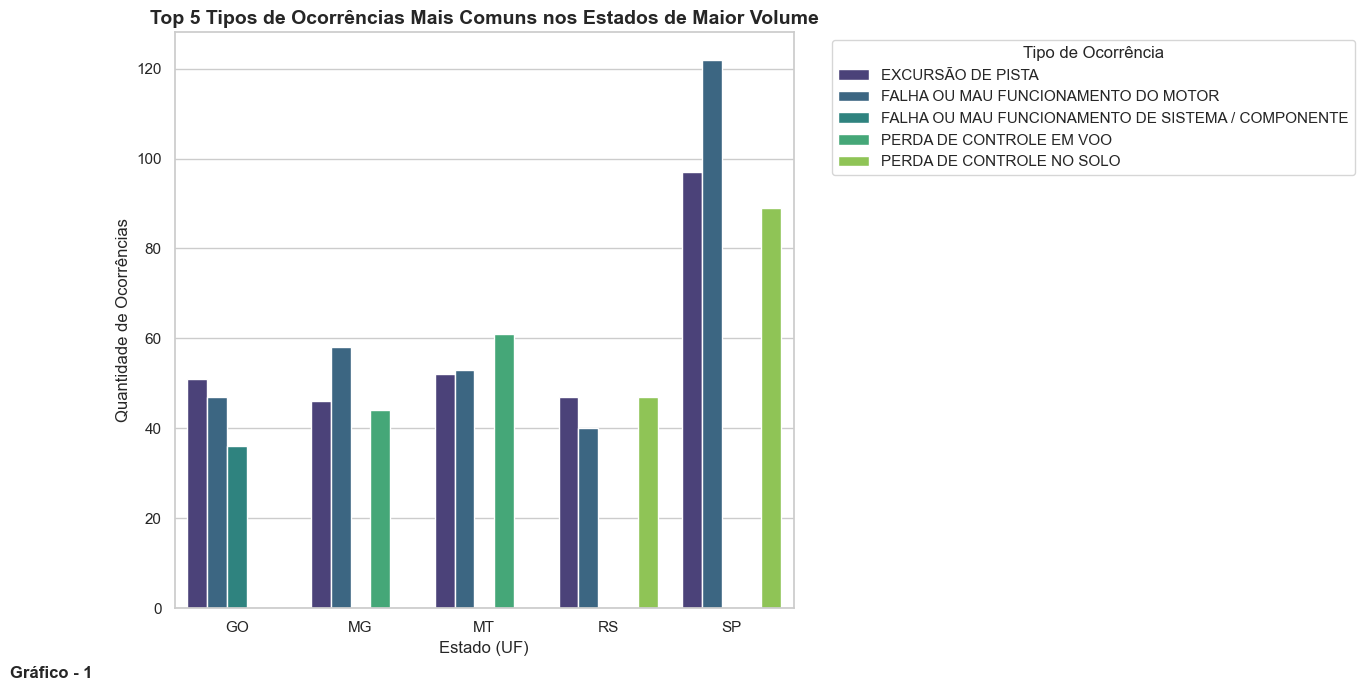

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

top5_estados = df['UF'].value_counts().head(5).index

df_top5 = df[df['UF'].isin(top5_estados)]
df_amostragem = df_top5.groupby(['UF', 'Descricao_do_Tipo']).size().reset_index(name='Quantidade')
df_amostragem = df_amostragem.groupby('UF').apply(lambda x: x.nlargest(3, 'Quantidade')).reset_index(drop=True)

plt.figure(figsize=(14, 7))
sns.barplot(data=df_amostragem, x='UF', y='Quantidade', hue='Descricao_do_Tipo', palette='viridis')

plt.title('Top 5 Tipos de Ocorrências Mais Comuns nos Estados de Maior Volume', fontsize=14, fontweight='bold')
plt.xlabel('Estado (UF)', fontsize=12)
plt.ylabel('Quantidade de Ocorrências', fontsize=12)
plt.legend(title='Tipo de Ocorrência', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.text(0.01, 0.02, 'Gráfico - 1', fontsize=12, weight='bold', transform=plt.gcf().transFigure)
plt.tight_layout()
plt.show()

O gráfico de linhas expõe uma análise detalhada de séries temporais. Pode-se ver que as regiões com mais acidentes a partir de 2012 é a região Sudeste (mais vôos comerciais/executivos) e a região Centro-Oeste (aviação agrícola).

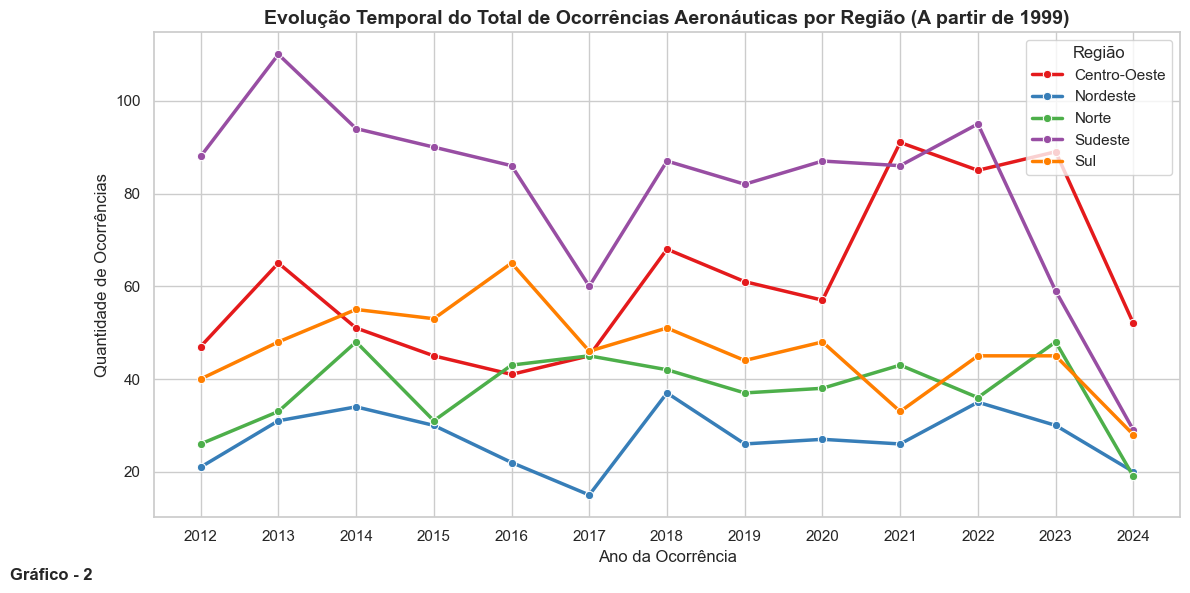

In [81]:
df_regiao_ano = df.groupby(['Regiao', 'Ano_da_Ocorrencia']).size().reset_index(name='Total_Ocorrencias')

df_filtrado = df_regiao_ano[df_regiao_ano['Ano_da_Ocorrencia'] >= 2012]

plt.figure(figsize=(12, 6))

sns.lineplot(data=df_filtrado, x='Ano_da_Ocorrencia', y='Total_Ocorrencias', hue='Regiao', marker='o', linewidth=2.5, palette='Set1')

plt.title('Evolução Temporal do Total de Ocorrências Aeronáuticas por Região (A partir de 1999)', fontsize=14, fontweight='bold')
plt.xlabel('Ano da Ocorrência', fontsize=12)
plt.ylabel('Quantidade de Ocorrências', fontsize=12)

plt.xticks(sorted(df_filtrado['Ano_da_Ocorrencia'].unique()))

plt.legend(title='Região')
plt.text(0.01, 0.02, 'Gráfico - 2', fontsize=12, weight='bold', transform=plt.gcf().transFigure)
plt.tight_layout()
plt.show()

Na aviação, a fase de Pouso costuma registrar a maior quantidade absoluta de ocorrências (Gráfico da esquerda) devido à complexidade da manobra e aproximação com o solo. No entanto, o gráfico da direita frequentemente prova que fases como Em Rota ou Cruzeiro, embora tenham menos ocorrências registradas, respondem por um volume drasticamente maior de vítimas fatais devido à energia cinética e severidade do impacto quando algo falha em alta altitude.

C:\Users\joads\AppData\Local\Temp\ipykernel_25544\2612910586.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fases_ocorrencias.values, y=fases_ocorrencias.index, ax=axes[0], palette='Blues_r')
C:\Users\joads\AppData\Local\Temp\ipykernel_25544\2612910586.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fatalidades_por_fase.values, y=fatalidades_por_fase.index, ax=axes[1], palette='Oranges_r')


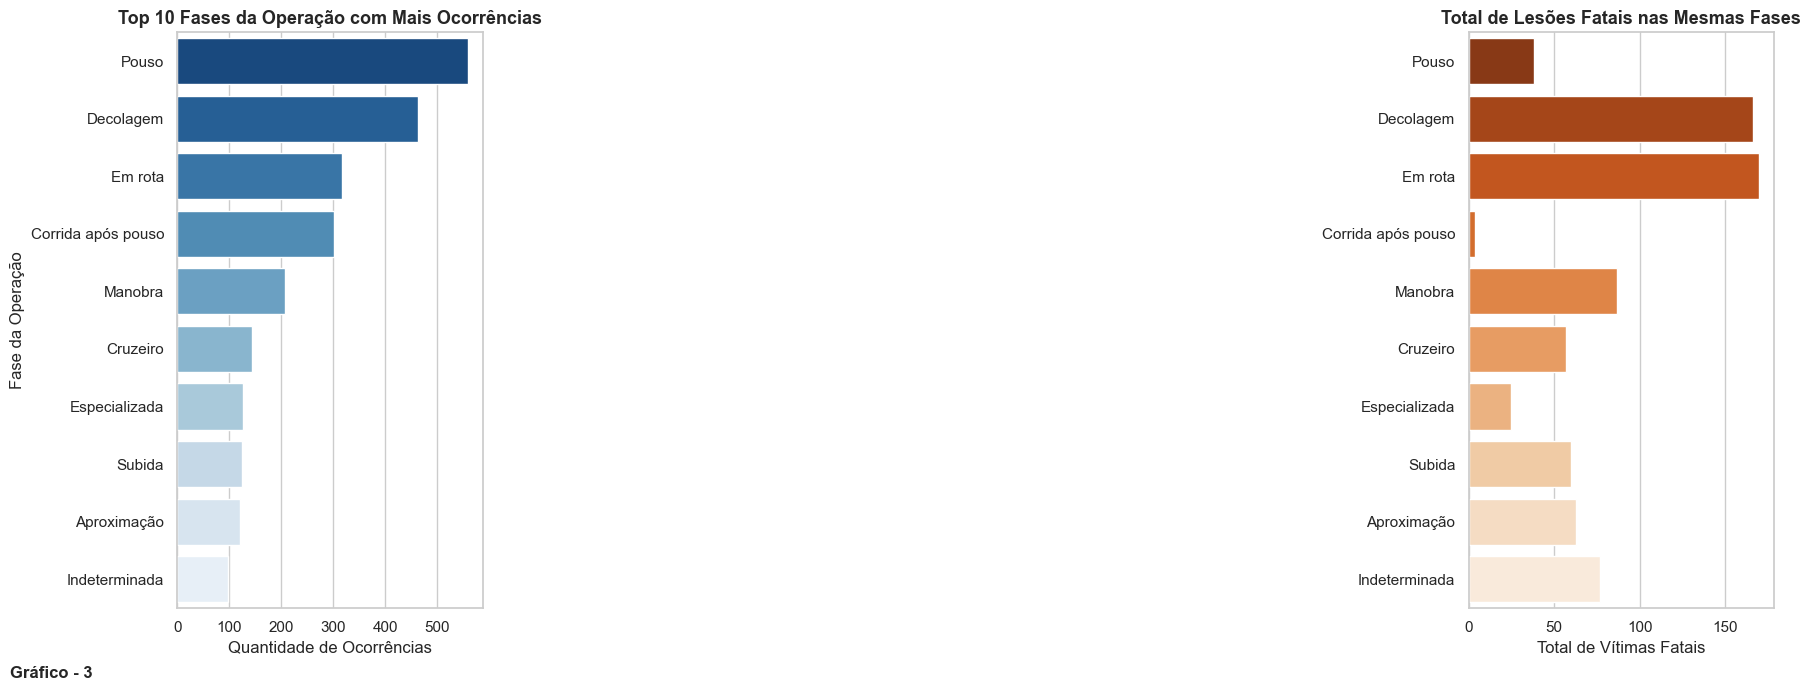

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

fases_ocorrencias = df_unico['Fase_da_Operacao'].value_counts().head(10)
sns.barplot(x=fases_ocorrencias.values, y=fases_ocorrencias.index, ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 10 Fases da Operação com Mais Ocorrências', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Quantidade de Ocorrências')
axes[0].set_ylabel('Fase da Operação')

fatalidades_por_fase = df_unico.groupby('Fase_da_Operacao')['Total_Lesoes_Fatais'].sum().loc[fases_ocorrencias.index]
sns.barplot(x=fatalidades_por_fase.values, y=fatalidades_por_fase.index, ax=axes[1], palette='Oranges_r')
axes[1].set_title('Total de Lesões Fatais nas Mesmas Fases', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Total de Vítimas Fatais')
axes[1].set_ylabel('')
plt.text(0.01, 0.02, 'Gráfico - 3', fontsize=12, weight='bold', transform=plt.gcf().transFigure)

plt.tight_layout()
plt.show()

O Mapa de Calor (Heatmap) converte números brutos em estímulos visuais de intensidade. Por exemplo, a categoria TPP (Privada) sofre massivamente com "Perda de Controle em Voo", enquanto outra categoria sofre muito mais com "Excursão de Pista", direcionando políticas específicas de treinamento para cada nicho.

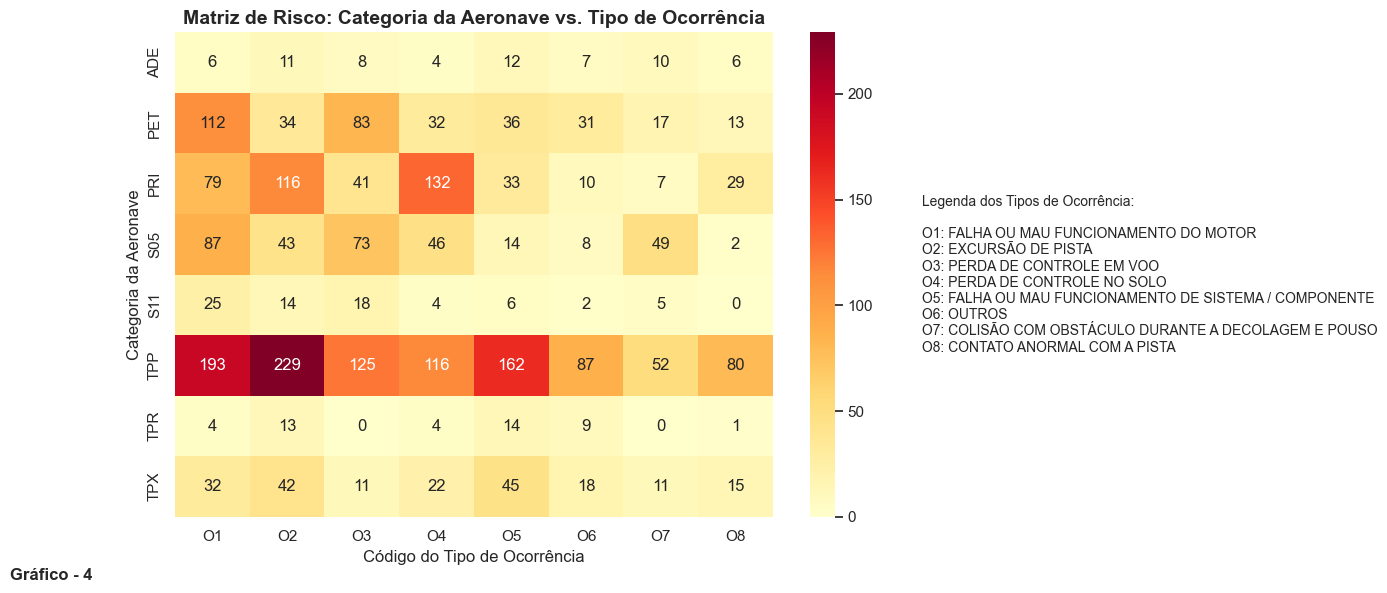

In [83]:
top_categorias = df['Categoria_da_Aeronave'].value_counts().head(8).index
top_tipos_ocorrencia = df['Descricao_do_Tipo'].value_counts().head(8).index

df_pivot = df[
    df['Categoria_da_Aeronave'].isin(top_categorias)
    & df['Descricao_do_Tipo'].isin(top_tipos_ocorrencia)
].copy()

mapeamento_tipos = {
    tipo: f'O{i+1}' for i, tipo in enumerate(top_tipos_ocorrencia)
}
df_pivot['Tipo_Curto'] = df_pivot['Descricao_do_Tipo'].map(mapeamento_tipos)

tabela_cruzada = pd.crosstab(
    df_pivot['Categoria_da_Aeronave'], df_pivot['Tipo_Curto']
)

colunas_ordenadas = [f'O{i+1}' for i in range(len(top_tipos_ocorrencia))]
tabela_cruzada = tabela_cruzada.reindex(columns=colunas_ordenadas)

fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(tabela_cruzada, annot=True, fmt='d', cmap='YlOrRd', cbar=True, ax=ax)

plt.title(
    'Matriz de Risco: Categoria da Aeronave vs. Tipo de Ocorrência',
    fontsize=14,
    fontweight='bold',
)
plt.xlabel('Código do Tipo de Ocorrência', fontsize=12)
plt.ylabel('Categoria da Aeronave', fontsize=12)

texto_legenda = '\n'.join(
    [f'{codigo}: {tipo}' for tipo, codigo in mapeamento_tipos.items()]
)

plt.text(
    1.25,
    0.5,
    f'Legenda dos Tipos de Ocorrência:\n\n{texto_legenda}',
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='center',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8),
)
plt.text(0.01, 0.02, 'Gráfico - 4', fontsize=12, weight='bold', transform=plt.gcf().transFigure)

plt.tight_layout()
plt.show()

Embasamento para a análise:

* Não existe uma relação causal direta entre o IDH (Índice de Desenvolvimento Humano) baixo de um estado e o aumento de acidentes aéreos. A aviação é uma atividade altamente globalizada e regulada por padrões internacionais estritos. Os fatores que provocam acidentes aeronáuticos estão ligados à operação e à infraestrutura técnica, e não aos índices sociais locais de onde o avião decola ou cai. No entanto o foco da análise foi selecionar os estado com menor IDH na amostra de dados para verificar quais as regiões em que os acidentes ocorrêm com mais frequência para respaldar o tipo de ação a ser tomada, se educativa ou focada na estrutura dos pontos de pouso e decolagem bem como se a atividade exercida pelas aeronaves não de cunho legal ou não. 

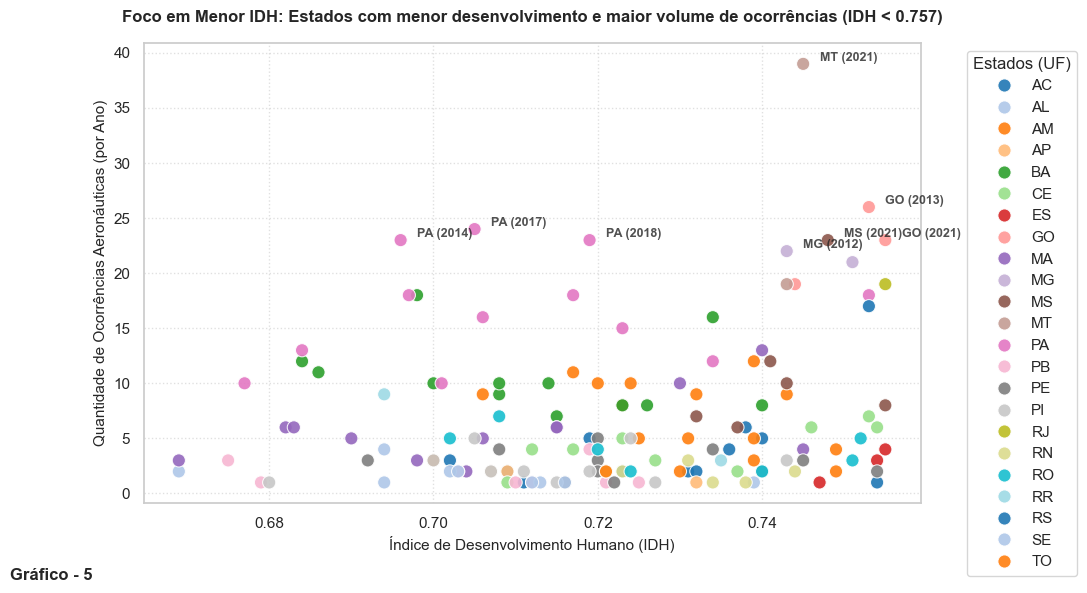

In [84]:
# --- 1. Preparação dos dados (CENIPA + IDH Longo) ---
df['Ano'] = pd.to_datetime(df['Data_da_Ocorrencia']).dt.year
df_ocorrencias_ano = df.groupby(['UF', 'Ano']).size().reset_index(name='Qtd_Ocorrencias')
df_correlacao = pd.merge(df_ocorrencias_ano, df_idh_final, on=['UF', 'Ano'], how='inner')

# --- 2. Definindo a linha de corte para "Menor IDH" ---
# Usaremos a mediana do IDH do período como linha de corte estatística
corte_idh = df_correlacao['IDH'].median()

# Filtramos a base: apenas estados/anos abaixo da mediana de IDH
df_baixo_idh = df_correlacao[df_correlacao['IDH'] < corte_idh].copy()

# --- 3. Construção do Gráfico de Dispersão ---
plt.figure(figsize=(11, 6))

# Usamos a paleta 'Set2' que destaca bem os pontos por UF (Estado)
sns.scatterplot(
    data=df_baixo_idh, 
    x='IDH', 
    y='Qtd_Ocorrencias', 
    hue='UF', 
    palette='tab20', 
    s=90, 
    alpha=0.9
)

# --- 4. DESTACANDO OS OUTLIERS (Estados com menor IDH e mais Ocorrências) ---
# Vamos encontrar os pontos mais altos do gráfico para colocar o nome do estado ao lado do ponto
top_ocorrencias = df_baixo_idh.nlargest(8, 'Qtd_Ocorrencias')

for idx, row in top_ocorrencias.iterrows():
    plt.text(
        row['IDH'] + 0.002, 
        row['Qtd_Ocorrencias'] + 0.3, 
        f"{row['UF']} ({row['Ano']})", 
        fontsize=9, 
        weight='bold',
        alpha=0.8
    )

# Customização técnica e estética do gráfico
plt.title(f'Foco em Menor IDH: Estados com menor desenvolvimento e maior volume de ocorrências (IDH < {corte_idh:.3f})', fontsize=12, pad=15, weight='bold')
plt.xlabel('Índice de Desenvolvimento Humano (IDH)', fontsize=11)
plt.ylabel('Quantidade de Ocorrências Aeronáuticas (por Ano)', fontsize=11)
plt.legend(title='Estados (UF)', bbox_to_anchor=(1.05, 1), loc='upper left') # Legenda para fora do gráfico
plt.grid(True, linestyle=':', alpha=0.6)
plt.text(0.01, 0.02, 'Gráfico - 5', fontsize=12, weight='bold', transform=plt.gcf().transFigure)

plt.tight_layout()
plt.show()



* O Destaque do Nordeste e Norte: Estados como Mato Grosso (MT), Bahia (BA) e Pará (PA) vão aparecer no topo desse gráfico em anos específicos. Embora eles estivessem na metade inferior do IDH da tabela naquele momento, eles pontuaram muito alto em número de acidentes.

* A Justificativa Geográfica e Setorial: O Pará (PA) e o Mato Grosso (MT) possuem características geográficas de isolamento e forte atividade de Aviação Agrícola (pulverização de lavouras) e Táxi Aéreo de garimpo/carga. Essas operações acontecem fora de aeródromos homologados (em pistas de terra de fazendas), o que gera um índice alto de incidentes operacionaisdescritos no CENIPA (como falha de motor ou perda de controle no pouso).

In [134]:
import pandas as pd

# Testando a leitura como arquivo de texto (CSV) separado por ponto e vírgula
# O parâmetro encoding='utf-8-sig' resolve o problema do caractere '\xef\xbb\xbf'
df_dados = pd.read_csv(r"C:\Users\joads\Documents\Français\2017-04.xls", sep=';', encoding='utf-8-sig')

print(f"\n--- BASE IDH: Carregadas {len(df_dados)} linhas de estados ---")
display(df_dados.head())


C:\Users\joads\AppData\Local\Temp\ipykernel_25544\3395631754.py:5: DtypeWarning: Columns (2,6,9,10,16,17,18,19,20,21,32) have mixed types. Specify dtype option on import or set low_memory=False.
  df_dados = pd.read_csv(r"C:\Users\joads\Documents\Français\2017-04.xls", sep=';', encoding='utf-8-sig')



--- BASE IDH: Carregadas 28707 linhas de estados ---


,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,Atualizado em: 2022-05-16
MARCA,PROPRIETARIO,OUTROS_PROPRIETARIOS,SG_UF,CPF_CNPJ,NM_OPERADOR,OUTROS_OPERADORES,UF_OPERADOR,CPF_CGC,NR_CERT_MATRICULA,NR_SERIE,CD_CATEGORIA,CD_TIPO,DS_MODELO,NM_FABRICANTE,CD_CLS,NR_PMD,CD_TIPO_ICAO,NR_TRIPULACAO_MIN,NR_PASSAGEIROS_MAX,NR_ASSENTOS,NR_ANO_FABRICACAO,DT_VALIDADE_IAM,DT_VALIDADE_CA,DT_CANC,DS_MOTIVO_CANC,CD_INTERDICAO,CD_MARCA_NAC1,CD_MARCA_NAC2,CD_MARCA_NAC3,CD_MARCA_ESTRANGEIRA,DS_GRAVAME,DT_MATRICULA
PPAAA,WELLS FARGO BANK NORTHWEST NAT.ASSOC,NaN,NaN,NaN,CIA.DE TEC.NORTE DE MINAS-COTEMINAS,NaN,750,22.677.520/0001-76,16646,7500234,TPP,C750,750,CESSNA AIRCRAFT,L2J,16375,NaN,2,9,11,2004,2014-02-11 00:00:00,2017-02-03 00:00:00,2013-06-27 00:00:00,REQ 100613-EXPORTADA,M,NaN,NaN,NaN,NaN,NaN,NaN
PPAAC,LIRIO PEDRO RIGON,NaN,RO,169.XXX.XXX-87,LIRIO PEDRO RIGON,NaN,R182,169.XXX.XXX-87,21795,NaN,TPP,MNTE,R182,CESSNA AIRCRAFT,L1P,1406,NaN,1,3,4,1978,2017-08-04 00:00:00,2019-05-07 00:00:00,NaN,NaN,N,NaN,NaN,NaN,N737MH,NaN,NaN
PPAAD,CONFEDERACAO BRASILEIRA DE FUTEBOL,NaN,RJ,33.655.721/0001-99,CONFEDERACAO BRASILEIRA DE FUTEBOL,NaN,680,33.655.721/0001-99,18166,NaN,TPP,C680,680,CESSNA AIRCRAFT,L2J,13744,NaN,2,9,11,2009,2018-02-24 00:00:00,2021-01-21 00:00:00,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN
PPAAE,HELICON TAXI AEREO LTDA,NaN,PR,13.013.997/0001-66,HELICON TAXI AEREO LTDA,NaN,R44,13.013.997/0001-66,18647,1996,M13,HMNC,R44,ROBINSON HELICOPTER,H1P,1088,NaN,1,3,4,2009,2018-03-01 00:00:00,2023-03-01 00:00:00,NaN,NaN,N,NaN,NaN,NaN,NaN,ARROLAMENTOS BENS REC.FED./INDISPONIVEL,NaN
